# **1- INTRODUCTION**

# 🎮 Gaming & Mental Health Data Analysis

**Team:** The Outliers  
**Members:** Mohamed Bedier, Belal Elkhamisy, Shahd Mohamed, Youssef Talaat, Ebrahim Elnemr
**Supervised by:** 💌Dr. Amal Mahmoud 💌

---

### 📌 Project Introduction
This project performs an advanced data analysis lifecycle on a comprehensive dataset mapping the intersection between video gaming habits and human psychological, behavioral, and physical well-being. The core mission is to unveil empirical evidence on how intensive gaming correlates with physical strain, sleep architecture, academic/professional productivity, and potential addiction risks.

---

### 📊 Dataset Overview & Star Schema Architecture
The data has been engineered from a flat structure into an optimized **Star Schema Relational Database Engine**, separating descriptive attributes into specialized Dimensions linked to a central Fact Table.

#### 1. 🔲 Central Fact Table
* **`Fact_Gaming_Mental_Health`**: Holds quantitative metrics and keys.
  * **Keys:** `record_id` (PK), `Addiction_Id` (FK), `Physical_Id` (FK), `Sleep_Id` (FK), `Game_Id` (FK), `Platform_Id` (FK)
  * **Metrics & Measures:** `daily_gaming_hours`, `Gaming_Hours_Category`, `sleep_hours`, `academic_work_performance`, `grades_gpa`, `work_productivity_score`, `mood_state`, `mood_swing_frequency`, `weight_change_kg`, `exercise_hours_weekly`, `social_isolation_score`, `face_to_face_social_hours_weekly`, `monthly_game_spending_usd`, `years_gaming`, `Total_spent`, `Spend_Category`

#### 2. 🔷 Dimension Tables
* **`Dim_Platform`**: `Platform_Id` (PK), `gaming_platform`
* **`Dim_Game`**: `Game_Id` (PK), `game_genre`, `primary_game`
* **`Dim_Player`**: `record_id` (PK), `age`, `Age_Group`, `gender`, `Educational_State`
* **`Dim_Sleep`**: `Sleep_Id` (PK), `sleep_quality`, `sleep_disruption_frequency`, `Sleep_State`
* **`Dim_Addiction`**: `Addiction_Id` (PK), `withdrawal_symptoms`, `loss_of_other_interests`, `continued_despite_problems`, `gaming_addiction_risk_level`
* **`Dim_PhysicalStatus`**: `Physical_Id` (PK), `eye_strain`, `back_neck_pain`, `Physical_Pain`

---

### 🛠️ End-to-End Pipeline Roadmap
Our execution map covers the fundamental phases of professional data analytics:

* ✅ **Data Quality Check:** Validated empty cells and handled missing entries dynamically by transforming text blanks into appropriate database `NULL` markers (e.g., `grades_gpa` & `work_productivity_score`).
* ✅ **Statistical Outlier Validation:** Enforced formal empirical checks leveraging the Standard Normal Distribution criteria ($\mu \pm 3\sigma$) to verify data purity.
* ✅ **Feature Engineering:** Expanded structural depth by computing complex behavioral dimensions such as `Total_spent`, statistical `Spend_Category`, `sleep_states`, `Educational_State`, `Physical_Pain` indexes, and custom `Gaming_Hours_Category`.
* ✅ **Data Modeling & ETL:** Designed the relational database architecture and executed ordered insert sequences populating the dimensional nodes before generating the fact connections.
* ✅ **Exploratory Data Analysis (EDA):** Queried cross-dimensional behavior using complex relational SQL aggregations (`GROUP BY`, `JOIN`, `Subqueries`).
* 🔄 **Data Visualization & Storytelling:** Connecting Python environments directly to the database via `SQLAlchemy`, using `Pandas`, `Matplotlib`, and `Seaborn` to reveal high-impact strategic insights.

# **2- IMPORT LIBRARIES**

In [2]:
import pandas as pd
import numpy as np

# Visualization libraries for plotting charts
import matplotlib.pyplot as plt
import seaborn as sns

# Streamlit for building the web app dashboard
!pip install streamlit -q
import streamlit as st

# SQLAlchemy tools for DB connection and ORM mapping
from sqlalchemy import create_engine, Column, Integer, String, Float, ForeignKey
from sqlalchemy.orm import declarative_base, relationship

# Library to generate and render ER diagrams
!pip install eralchemy2 -q
from eralchemy2 import render_er

# OS module for file paths and system operations
import os

print("Done")

Done


# **3- LOADING DATASET**

In [4]:
# Loading the dataset from a specific path
df = pd.read_csv("Gaming and Mental Health.csv")

# **4- BASIC INFORMATION ABOUT DATASET**

In [5]:
# Summary statistics for numerical columns (mean, min, max, etc.)
df.describe()

,age,daily_gaming_hours,sleep_hours,grades_gpa,work_productivity_score,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming
count,1000.000000,1000.000000,1000.000000,754.000000,674.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.475000,6.151400,5.738100,2.518037,5.394659,1.513400,6.945900,3.872000,7.654500,105.219730,5.796000
std,4.116105,2.867194,1.441213,0.872312,2.898742,1.432212,1.805027,2.091409,3.751954,113.886768,3.775532
min,13.000000,0.500000,3.000000,1.010000,1.000000,0.000000,0.700000,1.000000,0.000000,0.100000,1.000000
25%,18.000000,4.100000,4.800000,1.760000,3.000000,0.400000,5.700000,2.000000,5.000000,32.592500,3.000000
50%,20.000000,6.000000,5.700000,2.530000,5.000000,1.100000,7.000000,4.000000,8.000000,66.405000,5.000000
75%,22.000000,8.025000,6.600000,3.280000,8.000000,2.100000,8.200000,5.000000,10.400000,126.242500,8.000000
max,35.000000,15.100000,9.000000,4.000000,10.000000,8.900000,11.500000,10.000000,16.700000,499.270000,20.000000


In [6]:
# Check the number of rows and columns (dimensions of the dataframe)
print(df.shape)

(1000, 27)


In [7]:
# Display dataframe summary, including data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   record_id                         1000 non-null   object 
 1   age                               1000 non-null   int64  
 2   gender                            1000 non-null   object 
 3   daily_gaming_hours                1000 non-null   float64
 4   game_genre                        1000 non-null   object 
 5   primary_game                      1000 non-null   object 
 6   gaming_platform                   1000 non-null   object 
 7   sleep_hours                       1000 non-null   float64
 8   sleep_quality                     1000 non-null   object 
 9   sleep_disruption_frequency        1000 non-null   object 
 10  academic_work_performance         1000 non-null   object 
 11  grades_gpa                        754 non-null    float64
 12  work_pr

In [8]:
# Preview the first 5 rows of the dataset
df.head()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
0,GD0001,17,Male,11.1,Mobile Games,Clash of Clans,PC,3.7,Very Poor,Sometimes,...,True,True,False,6.8,3.7,7,1.3,383.70,3,Severe
1,GD0002,21,Male,3.0,MOBA,Dota 2,PC,7.2,Fair,Rarely,...,False,False,False,0.4,8.5,2,10.7,46.64,1,Low
2,GD0003,23,Male,7.6,FPS,CS:GO,Multi-platform,4.4,Fair,Often,...,True,False,True,1.8,7.1,5,3.2,100.81,6,Severe
3,GD0004,20,Female,7.2,RPG,Skyrim,Multi-platform,5.1,Fair,Often,...,False,True,True,0.2,5.2,4,9.1,51.60,7,High
4,GD0005,18,Male,6.8,Battle Royale,Apex Legends,PC,3.4,Poor,Never,...,False,False,False,0.5,6.1,4,4.5,32.57,1,Moderate


In [9]:
# Preview the last 5 rows of the dataset
df.tail()

,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
995,GD0996,15,Female,8.6,Strategy,Age of Empires,PC,4.1,Very Poor,Always,...,True,True,True,1.9,7.5,6,2.4,426.54,3,Severe
996,GD0997,18,Male,5.4,MMO,Elder Scrolls Online,Multi-platform,6.5,Fair,Never,...,False,True,False,2.1,7.7,1,10.9,83.71,7,Low
997,GD0998,23,Male,7.3,RPG,Skyrim,PC,3.9,Insomnia,Rarely,...,False,False,True,0.5,8.1,5,6.7,88.60,5,High
998,GD0999,18,Male,3.1,Strategy,StarCraft II,Console,8.2,Fair,Sometimes,...,False,False,False,0.8,8.4,1,12.7,22.02,8,Low
999,GD1000,29,Male,3.5,RPG,Cyberpunk 2077,Multi-platform,7.4,Good,Sometimes,...,False,False,False,0.0,9.3,2,10.9,25.20,19,Low


# **5- Statistics**

# **1) Descriptive Statistics of Numeric Variables**

In [10]:
# Calculate mean and standard deviation for gaming hours
mean = df["daily_gaming_hours"].mean()
std = df["daily_gaming_hours"].std()

# Define thresholds for outliers using the 3-sigma rule
lower_bound = mean - 3 * std
upper_bound = mean + 3 * std

# Filter the dataframe to isolate the outliers
outliers_df = df[(df["daily_gaming_hours"] < lower_bound) | (df["daily_gaming_hours"] > upper_bound)]

# Print the threshold limits and the count of detected outliers
print(f"Lower Bound : {lower_bound:.2f}")
print(f"Upper Bound : {upper_bound:.2f}")
print(f"Total Outliers Found : {len(outliers_df)}")

print("\n------------------------------------------------\n")

# Display outlier rows if they exist, otherwise confirm none were found
if not outliers_df.empty:
    display(outliers_df)
else:
    print("\nNo outliers found")

Lower Bound : -2.45
Upper Bound : 14.75
Total Outliers Found : 2

------------------------------------------------



,record_id,age,gender,daily_gaming_hours,game_genre,primary_game,gaming_platform,sleep_hours,sleep_quality,sleep_disruption_frequency,...,continued_despite_problems,eye_strain,back_neck_pain,weight_change_kg,exercise_hours_weekly,social_isolation_score,face_to_face_social_hours_weekly,monthly_game_spending_usd,years_gaming,gaming_addiction_risk_level
69,GD0070,18,Female,15.1,MMO,World of Warcraft,PC,4.8,Fair,Often,...,False,True,True,0.0,4.2,10,0.0,209.75,6,High
258,GD0259,15,Male,15.1,Strategy,Age of Empires,Multi-platform,5.7,Fair,Sometimes,...,False,True,True,1.5,0.7,9,0.0,435.38,2,Moderate


In [11]:
# Get all numerical columns in the dataframe
numeric_cols = df.select_dtypes(include=['number']).columns

print("🔍 Outliers Check (Standard Deviation Method):\n")

# Loop through each numerical column to detect outliers
for col in numeric_cols:

    # Calculate mean and standard deviation
    mean = df[col].mean()
    std = df[col].std()

    # Define lower and upper limits using the 3-sigma rule
    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std

    # Filter data points that fall outside the bounds
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # Print the outlier count for the current column
    print(f"📌 {col}: {len(outliers)} outliers found")

print("\n✅ Done checking all numerical columns!")

🔍 Outliers Check (Standard Deviation Method):

📌 age: 16 outliers found
📌 daily_gaming_hours: 2 outliers found
📌 sleep_hours: 0 outliers found
📌 grades_gpa: 0 outliers found
📌 work_productivity_score: 0 outliers found
📌 weight_change_kg: 17 outliers found
📌 exercise_hours_weekly: 2 outliers found
📌 social_isolation_score: 0 outliers found
📌 face_to_face_social_hours_weekly: 0 outliers found
📌 monthly_game_spending_usd: 21 outliers found
📌 years_gaming: 11 outliers found

✅ Done checking all numerical columns!


# **2) inferential statistics**

# **1. Independent Two-Sample T-Test**

T-statistic: 23.25541954030809
p-value: 8.030800042034154e-70
Statistically significant result: There is a real difference in the average sleep hours between the two groups.


C:\Users\bebawy\AppData\Local\Temp\ipykernel_18296\782132292.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gaming_addiction_risk_level', y='sleep_hours', data=df_filtered, palette='Set2')


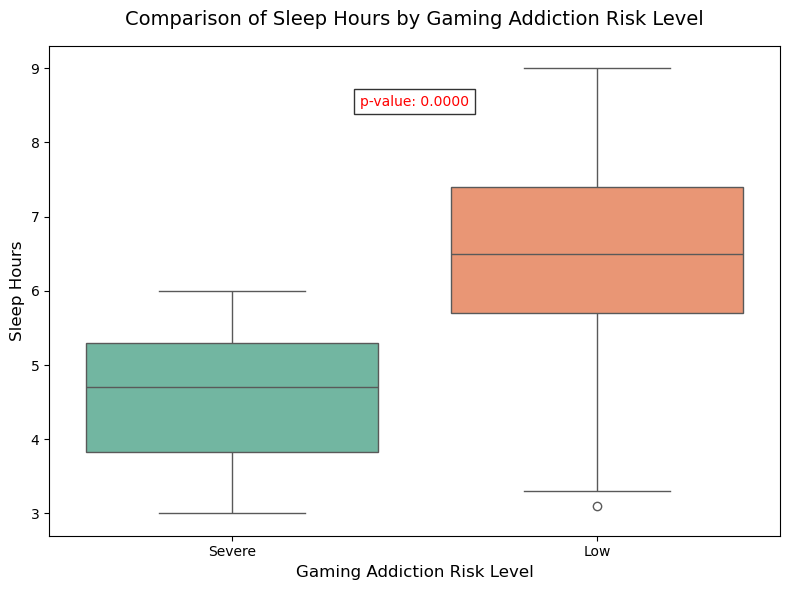

In [13]:
# ==========================================================================================
# CONCEPT:
# The goal is to determine whether the difference between the means of two independent groups
# (e.g., Low vs. Severe Gaming Addiction) is statistically significant.
# ==========================================================================================

# Separate the two groups (sleep hours for Low and Severe addiction risk levels)
Low_Addiction = df[df['gaming_addiction_risk_level'] == 'Low']['sleep_hours'].dropna()
Severe_Addiction = df[df['gaming_addiction_risk_level'] == 'Severe']['sleep_hours'].dropna()

# Execute the independent t-test
t_stat, p_val = stats.ttest_ind(Low_Addiction, Severe_Addiction, equal_var=False)

print(f"T-statistic: {t_stat}")
print(f"p-value: {p_val}")

if p_val < 0.05:
    print("Statistically significant result: There is a real difference in the average sleep hours between the two groups.")
else:
    print("Not significant result: The differences might be due to chance.")

# ==========================================================================================
# CHART GENERATION:
# ==========================================================================================
# Filter data to display only the two target groups in the chart
df_filtered = df[df['gaming_addiction_risk_level'].isin(['Low', 'Severe'])]

plt.figure(figsize=(8, 6))

# Draw a Boxplot to compare the distribution of sleep hours
sns.boxplot(x='gaming_addiction_risk_level', y='sleep_hours', data=df_filtered, palette='Set2')

# Add titles and details
plt.title('Comparison of Sleep Hours by Gaming Addiction Risk Level', fontsize=14, pad=15)
plt.xlabel('Gaming Addiction Risk Level', fontsize=12)
plt.ylabel('Sleep Hours', fontsize=12)

# Add p-value to the chart for statistical clarity
plt.text(0.5, df_filtered['sleep_hours'].max() * 0.95, f'p-value: {p_val:.4f}', 
         ha='center', va='center', color='red', bbox=dict(facecolor='white', alpha=0.8))

# Display the chart
plt.tight_layout()
plt.show()

# **2. One-Way ANOVA (Analysis of Variance)**

F-statistic: 865.561328532795, p-value: 4.530010604486178e-205
Statistically significant result: At least one group differs in mean gaming hours from the others.


C:\Users\bebawy\AppData\Local\Temp\ipykernel_18296\941255498.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gaming_addiction_risk_level', y='daily_gaming_hours',


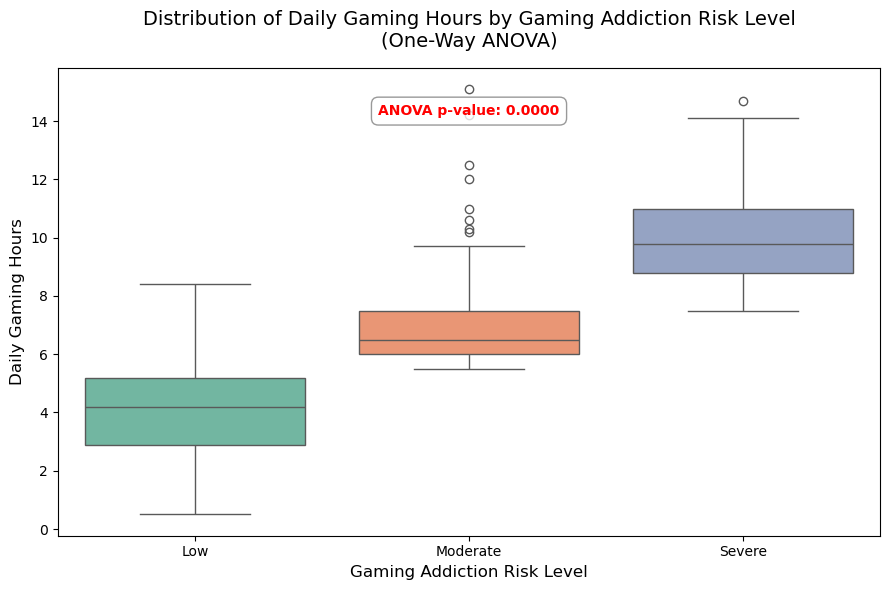

In [17]:
# ==========================================================================================
# CONCEPT:
# When comparing the means of more than two groups (e.g., three different addiction risk levels:
# Low, Moderate, Severe), using multiple T-tests increases the Type I error rate.
# ANOVA solves this by analyzing data variance; it compares the variance *between* the groups
# to the variance *within* the groups. If the variation between groups is significantly larger
# than the internal fluctuation, the p-value will be < 0.05, meaning that the categorical classification
# significantly impacts the numerical variable (daily gaming hours).
# ==========================================================================================

# Separate the groups based on gaming addiction risk levels
low_risk = df[df['gaming_addiction_risk_level'] == 'Low']['daily_gaming_hours'].dropna()
mod_risk = df[df['gaming_addiction_risk_level'] == 'Moderate']['daily_gaming_hours'].dropna()
severe_risk = df[df['gaming_addiction_risk_level'] == 'Severe']['daily_gaming_hours'].dropna()

# Execute the One-Way ANOVA test
f_stat, p_val = stats.f_oneway(low_risk, mod_risk, severe_risk)

print(f"F-statistic: {f_stat}, p-value: {p_val}")

if p_val < 0.05:
    print("Statistically significant result: At least one group differs in mean gaming hours from the others.")
else:
    print("Not significant: No statistically significant differences between the groups.")

# ==========================================================================================
# CHART GENERATION:
# ==========================================================================================
# 1. Filter data to ensure only the three target groups are displayed
df_filtered = df[df['gaming_addiction_risk_level'].isin(['Low', 'Moderate', 'Severe'])]

# 2. Define the logical order for the X-axis
group_order = ['Low', 'Moderate', 'Severe']

# 3. Set up the figure size
plt.figure(figsize=(9, 6))

# 4. Create a Boxplot to visualize the distribution of gaming hours for each risk level
sns.boxplot(x='gaming_addiction_risk_level', y='daily_gaming_hours', 
            data=df_filtered, order=group_order, palette='Set2')

# 5. Add titles and labels
plt.title('Distribution of Daily Gaming Hours by Gaming Addiction Risk Level\n(One-Way ANOVA)', fontsize=14, pad=15)
plt.xlabel('Gaming Addiction Risk Level', fontsize=12)
plt.ylabel('Daily Gaming Hours', fontsize=12)

# 6. Add the p-value to the chart dynamically
max_y = df_filtered['daily_gaming_hours'].max()
plt.text(1, max_y * 0.95, f'ANOVA p-value: {p_val:.4f}', 
         ha='center', va='center', color='red', weight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))

# 7. Adjust layout and show the plot
plt.tight_layout()
plt.show()

# **3. Chi-Square Test of Independence**

Chi-Square Stat: 8.896045441531331
p-value: 0.44692501304470955
Not significant: No statistical relationship; the distribution might be random.


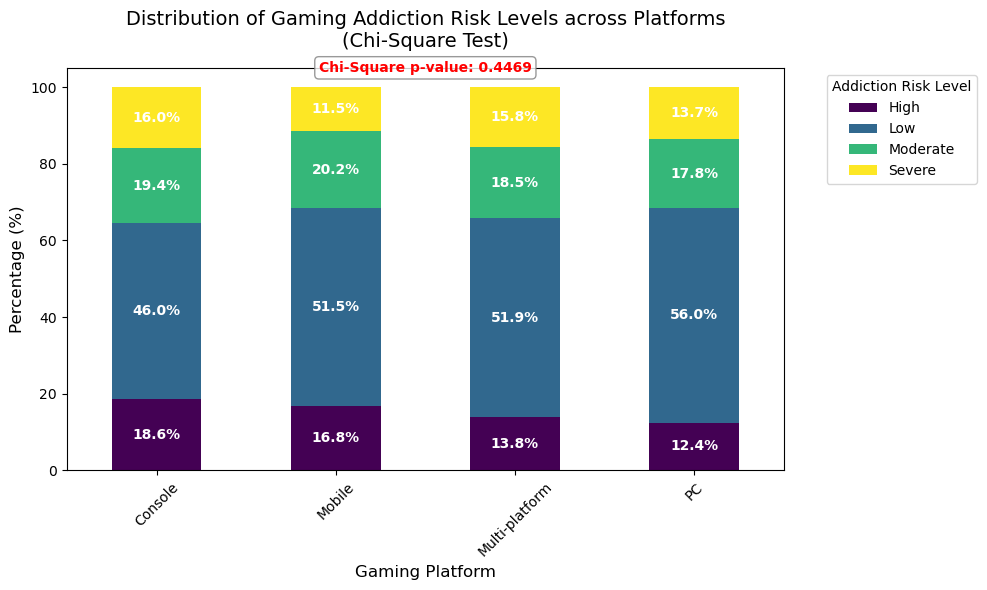

In [18]:
# ==========================================================================================
# CONCEPT:
# Chi-Square Test of Independence for categorical variables.
# Measures the association between gaming platform and addiction risk level.
# ==========================================================================================

# Create the contingency table between categorical variables
contingency_table = pd.crosstab(df['gaming_platform'], df['gaming_addiction_risk_level'])

# Execute the Chi-Square test of independence
chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi-Square Stat: {chi2}")
print(f"p-value: {p_val}")

if p_val < 0.05:
    print("Significant result: There is a statistically significant relationship between the gaming platform and the addiction risk level.")
else:
    print("Not significant: No statistical relationship; the distribution might be random.")

# ==========================================================================================
# CHART GENERATION:
# ==========================================================================================
# Convert contingency table to percentages for fair visualization
contingency_pct = pd.crosstab(df['gaming_platform'], df['gaming_addiction_risk_level'], normalize='index') * 100

# Plot stacked bar chart
ax = contingency_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

# Add titles and labels
plt.title('Distribution of Gaming Addiction Risk Levels across Platforms\n(Chi-Square Test)', fontsize=14, pad=15)
plt.xlabel('Gaming Platform', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45) 
plt.legend(title='Addiction Risk Level', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add p-value to the chart
plt.text(len(contingency_pct)/2 - 0.5, 105, f'Chi-Square p-value: {p_val:.4f}', 
         ha='center', va='center', color='red', weight='bold',
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.3'))

# Display percentages inside the bars for better readability
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    if height > 5: # Only show text if the bar segment is large enough
        x, y = p.get_xy() 
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', ha='center', va='center', color='white', weight='bold')

plt.tight_layout()
plt.show()

# **4. Linear Regression (OLS)**

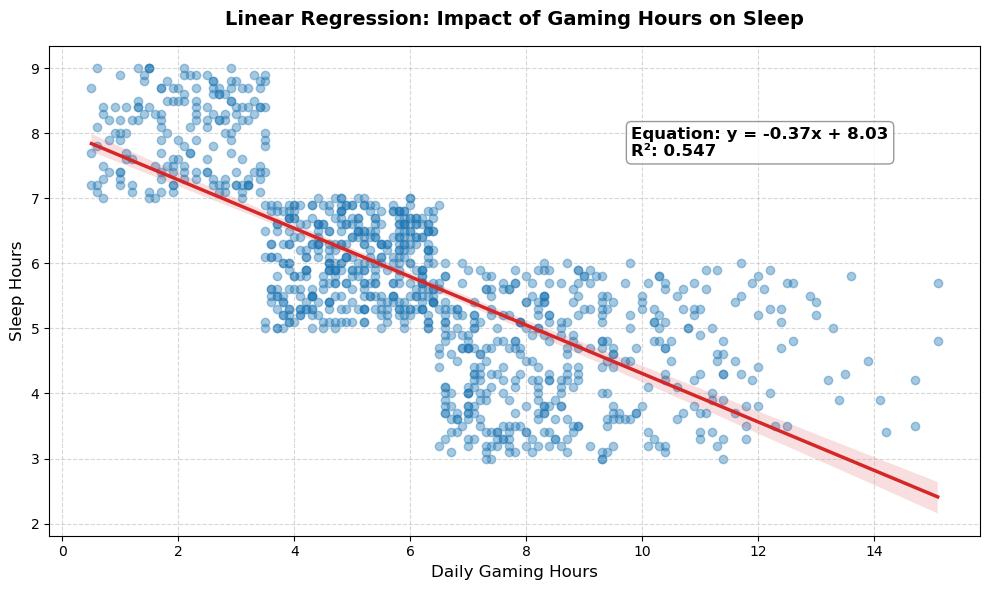

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# ==========================================================================================
# CONCEPT:
# While descriptive correlation only describes the strength of association, linear regression
# goes further to model predictive and causal-like relationships. It fits the best straight
# line through the data (y = mx + c), where the independent variable (X, daily gaming hours)
# acts as the predictor, and the dependent variable (y, sleep hours) acts as the outcome.
# This script visualizes the OLS model instantly via a Scatter Plot with a Regression Line,
# embedding the R-squared and model equation directly onto the chart.
# ==========================================================================================

# 1. Clean data from missing values
regression_data = df[['daily_gaming_hours', 'sleep_hours']].dropna()

X = regression_data['daily_gaming_hours']
y = regression_data['sleep_hours']

# 2. Calculate model parameters in the background
X_with_const = sm.add_constant(X)
model = sm.OLS(y, X_with_const).fit()

# Extract parameters (slope, intercept, and R-squared)
intercept = model.params['const']
slope = model.params['daily_gaming_hours']
r_squared = model.rsquared

# Prepare stats text for the chart
stats_text = f"Equation: y = {slope:.2f}x + {intercept:.2f}\nR²: {r_squared:.3f}"

# 3. Build and style the chart
plt.figure(figsize=(10, 6))

# Plot scatter points and regression line
sns.regplot(
    x='daily_gaming_hours',
    y='sleep_hours',
    data=regression_data,
    scatter_kws={'alpha': 0.4, 'color': '#1f77b4'}, # Transparent points to show density
    line_kws={'color': '#d62728', 'linewidth': 2.5}  # Regression line in red
)

# Add stats text to the chart
plt.text(
    x=regression_data['daily_gaming_hours'].max() * 0.65,
    y=regression_data['sleep_hours'].max() * 0.85,
    s=stats_text,
    fontsize=12,
    fontweight='bold',
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.8)
)

# Set titles, labels, and grid
plt.title('Linear Regression: Impact of Gaming Hours on Sleep', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Daily Gaming Hours', fontsize=12)
plt.ylabel('Sleep Hours', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.tight_layout()
plt.show()

# **6- Exploratory Data Analysis**

In [21]:
# Count missing (null) values in each column
df.isnull().sum()

record_id                             0
age                                   0
gender                                0
daily_gaming_hours                    0
game_genre                            0
primary_game                          0
gaming_platform                       0
sleep_hours                           0
sleep_quality                         0
sleep_disruption_frequency            0
academic_work_performance             0
grades_gpa                          246
work_productivity_score             326
mood_state                            0
mood_swing_frequency                  0
withdrawal_symptoms                   0
loss_of_other_interests               0
continued_despite_problems            0
eye_strain                            0
back_neck_pain                        0
weight_change_kg                      0
exercise_hours_weekly                 0
social_isolation_score                0
face_to_face_social_hours_weekly      0
monthly_game_spending_usd             0


In [22]:
# Check for duplicate entries based on the unique record identifier
duplicates = df["record_id"].duplicated().sum()
print(f"Duplicates: {duplicates}")

Duplicates: 0


# **7- Data Prepossessing**

In [23]:
# Create age groups based on predefined age ranges
df["age_group"] = df["age"].apply(
    lambda age: "Teenager" if age <= 18 else
              "Young_Adult" if age <= 28 else
              "Adult"
)

In [24]:
# View a subset of the dataframe to check the age bucketing results
df[["age", "age_group"]]

,age,age_group
0,17,Teenager
1,21,Young_Adult
2,23,Young_Adult
3,20,Young_Adult
4,18,Teenager
...,...,...
995,15,Teenager
996,18,Teenager
997,23,Young_Adult
998,18,Teenager


In [25]:
# Segment individuals into employment/academic statuses based on data availability
df["educational_state"] = df.apply(
    lambda row: "Working_Student" if pd.notna(row["grades_gpa"]) and pd.notna(row["work_productivity_score"]) else
                "Student" if pd.notna(row["grades_gpa"]) else
                "Worker" if pd.notna(row["work_productivity_score"]) else
                "Unknown",
    axis=1
)

In [26]:
# Verify the custom status logic by inspecting the relevant columns
df[["educational_state", "grades_gpa","work_productivity_score"]]

,educational_state,grades_gpa,work_productivity_score
0,Student,1.25,NaN
1,Working_Student,3.75,2.0
2,Worker,NaN,9.0
3,Working_Student,1.62,2.0
4,Student,2.44,NaN
...,...,...,...
995,Student,2.96,NaN
996,Student,3.42,NaN
997,Worker,NaN,3.0
998,Student,1.03,NaN


In [27]:
# Categorize sleep quality based on the total hours of sleep
df["sleep_state"] = df["sleep_hours"].apply(
    lambda sleep_hour: "Poor" if sleep_hour <= 4 else
              "Healthy" if sleep_hour <= 8 else
              "over_sleep"
)

In [28]:
# Verify the sleep bucketing results by inspecting the columns
df[["sleep_state", "sleep_hours"]]

,sleep_state,sleep_hours
0,Poor,3.7
1,Healthy,7.2
2,Healthy,4.4
3,Healthy,5.1
4,Poor,3.4
...,...,...
995,Healthy,4.1
996,Healthy,6.5
997,Poor,3.9
998,over_sleep,8.2


In [29]:
# Bin gaming hours dynamically using mean and standard deviation thresholds
avg_gaming_hours = df["daily_gaming_hours"].mean()
std_gaming_hours = df["daily_gaming_hours"].std()

df["gaming_hours_category"] = df["daily_gaming_hours"].apply(
    lambda gaming_hour: "Low" if gaming_hour < avg_gaming_hours else
              "Medium" if gaming_hour <= avg_gaming_hours + std_gaming_hours else
              "High" if gaming_hour <= avg_gaming_hours + 2*std_gaming_hours else
                "Very High"
)

In [30]:
# Verify the dynamic gaming categories by inspecting the columns
df[["gaming_hours_category", "daily_gaming_hours"]]

,gaming_hours_category,daily_gaming_hours
0,High,11.1
1,Low,3.0
2,Medium,7.6
3,Medium,7.2
4,Medium,6.8
...,...,...
995,Medium,8.6
996,Low,5.4
997,Medium,7.3
998,Low,3.1


In [31]:
# Derive lifetime gaming expenditure by extrapolating monthly spending over total gaming years
df["total_spent"] = (df["monthly_game_spending_usd"] * 12 * df["years_gaming"]).round(2)

In [32]:
# Inspect the derived lifetime expenditure alongside its base features to verify accuracy
df[["total_spent", "monthly_game_spending_usd","years_gaming"]]

,total_spent,monthly_game_spending_usd,years_gaming
0,13813.20,383.70,3
1,559.68,46.64,1
2,7258.32,100.81,6
3,4334.40,51.60,7
4,390.84,32.57,1
...,...,...,...
995,15355.44,426.54,3
996,7031.64,83.71,7
997,5316.00,88.60,5
998,2113.92,22.02,8


In [33]:
# Bin the lifetime expenditure dynamically using mean and standard deviation thresholds
avg_spent = df['total_spent'].mean()
std_spent = df['total_spent'].std()


df['Spend_Category'] = df['total_spent'].apply(
    lambda total_spent: 'Low' if total_spent <= avg_spent else
            'Mid' if total_spent <= (avg_spent + std_spent) else
            'High' if total_spent <= (avg_spent + 2 * std_spent) else
            'Very High'
)

In [34]:
# Verify the dynamic spending categories by inspecting the columns
df[['total_spent', 'Spend_Category']]

,total_spent,Spend_Category
0,13813.20,Mid
1,559.68,Low
2,7258.32,Mid
3,4334.40,Low
4,390.84,Low
...,...,...
995,15355.44,Mid
996,7031.64,Low
997,5316.00,Low
998,2113.92,Low


In [35]:
# Evaluate overall physical health risks based on visual and musculoskeletal strain indicators
df["physical_pain"] = df.apply(
    lambda row: "High_Risk" if row["eye_strain"] and row["back_neck_pain"] else
                "Moderate" if row["eye_strain"] or row["back_neck_pain"] else
                "Low_Risk",
    axis=1
)

In [36]:
# Inspect the derived physical pain risks alongside back and neck pain indicators to check consistency
df[['physical_pain', 'back_neck_pain']]

,physical_pain,back_neck_pain
0,Moderate,False
1,Low_Risk,False
2,Moderate,True
3,High_Risk,True
4,Low_Risk,False
...,...,...
995,High_Risk,True
996,Moderate,False
997,Moderate,True
998,Low_Risk,False


# **8- Data Modeling**

In [37]:
import pandas as pd
import sqlite3


# 1. Create an in-memory SQLite database connection
conn = sqlite3.connect(":memory:")

# 2. Write the main dataframe to a staging table in SQLite
df.to_sql("staging_df", conn, index=False, if_exists="replace")

# ==========================================
# 3. CREATE DIMENSION TABLES USING SQL
# ==========================================

# -- Dim Platform --
conn.execute("""
CREATE TABLE dim_platform (
    platform_id INTEGER PRIMARY KEY AUTOINCREMENT,
    gaming_platform TEXT UNIQUE
);
""")
conn.execute("""
INSERT INTO dim_platform (gaming_platform)
SELECT DISTINCT gaming_platform FROM staging_df WHERE gaming_platform IS NOT NULL;
""")

# -- Dim Game --
conn.execute("""
CREATE TABLE dim_game (
    game_id INTEGER PRIMARY KEY AUTOINCREMENT,
    game_genre TEXT,
    primary_game TEXT,
    UNIQUE(game_genre, primary_game)
);
""")
conn.execute("""
INSERT INTO dim_game (game_genre, primary_game)
SELECT DISTINCT game_genre, primary_game FROM staging_df;
""")

# -- Dim Sleep --
conn.execute("""
CREATE TABLE dim_sleep (
    sleep_id INTEGER PRIMARY KEY AUTOINCREMENT,
    sleep_quality TEXT,
    sleep_disruption_frequency TEXT,
    sleep_state TEXT,
    UNIQUE(sleep_quality, sleep_disruption_frequency, sleep_state)
);
""")
conn.execute("""
INSERT INTO dim_sleep (sleep_quality, sleep_disruption_frequency, sleep_state)
SELECT DISTINCT sleep_quality, sleep_disruption_frequency, sleep_state FROM staging_df;
""")

# -- Dim Addiction --
conn.execute("""
CREATE TABLE dim_addiction (
    addiction_id INTEGER PRIMARY KEY AUTOINCREMENT,
    withdrawal_symptoms TEXT,
    loss_of_other_interests TEXT,
    continued_despite_problems TEXT,
    gaming_addiction_risk_level TEXT,
    UNIQUE(withdrawal_symptoms, loss_of_other_interests, continued_despite_problems, gaming_addiction_risk_level)
);
""")
conn.execute("""
INSERT INTO dim_addiction (withdrawal_symptoms, loss_of_other_interests, continued_despite_problems, gaming_addiction_risk_level)
SELECT DISTINCT withdrawal_symptoms, loss_of_other_interests, continued_despite_problems, gaming_addiction_risk_level FROM staging_df;
""")

# -- Dim Physical --
conn.execute("""
CREATE TABLE dim_physical (
    physical_id INTEGER PRIMARY KEY AUTOINCREMENT,
    eye_strain TEXT,
    back_neck_pain TEXT,
    physical_pain TEXT,
    UNIQUE(eye_strain, back_neck_pain, physical_pain)
);
""")
conn.execute("""
INSERT INTO dim_physical (eye_strain, back_neck_pain, physical_pain)
SELECT DISTINCT eye_strain, back_neck_pain, physical_pain FROM staging_df;
""")

# -- Dim Player --
conn.execute("""
CREATE TABLE dim_player (
    record_id TEXT PRIMARY KEY,
    age INTEGER,
    age_group TEXT,
    gender TEXT,
    educational_state TEXT
);
""")
conn.execute("""
INSERT INTO dim_player (record_id, age, age_group, gender, educational_state)
SELECT DISTINCT record_id, age, age_group, gender, educational_state FROM staging_df;
""")


# ==========================================
# 4. CREATE FACT TABLE USING SQL JOINS
# ==========================================

fact_table_query = """
CREATE TABLE fact_table AS
SELECT
    s.record_id,
    s.gender,

    -- Foreign Keys from Dimension Tables
    dp.platform_id,
    g.game_id,
    sl.sleep_id,
    a.addiction_id,
    ph.physical_id,

    -- Gaming Measures
    s.daily_gaming_hours,
    s.gaming_hours_category,
    s.years_gaming,

    -- Spending Measures
    s.monthly_game_spending_usd,
    s.total_spent,
    s.Spend_Category,

    -- Sleep Measures
    s.sleep_hours,
    s.sleep_state,

    -- Academic and Work Measures
    s.academic_work_performance,
    s.grades_gpa,
    s.work_productivity_score,

    -- Mental Health Measures
    s.mood_state,
    s.mood_swing_frequency,

    -- Physical Health Measures
    s.weight_change_kg,
    s.exercise_hours_weekly,

    -- Social Measures
    s.social_isolation_score,
    s.face_to_face_social_hours_weekly

FROM staging_df s
LEFT JOIN dim_platform dp ON s.gaming_platform = dp.gaming_platform
LEFT JOIN dim_game g     ON s.game_genre = g.game_genre AND s.primary_game = g.primary_game
LEFT JOIN dim_sleep sl   ON s.sleep_quality = sl.sleep_quality AND s.sleep_disruption_frequency = sl.sleep_disruption_frequency AND s.sleep_state = sl.sleep_state
LEFT JOIN dim_addiction a ON s.withdrawal_symptoms = a.withdrawal_symptoms
                        AND s.loss_of_other_interests = a.loss_of_other_interests
                        AND s.continued_despite_problems = a.continued_despite_problems
                        AND s.gaming_addiction_risk_level = a.gaming_addiction_risk_level
LEFT JOIN dim_physical ph ON s.eye_strain = ph.eye_strain
                        AND s.back_neck_pain = ph.back_neck_pain
                        AND s.physical_pain = ph.physical_pain;
"""

conn.execute(fact_table_query)


# ==========================================
# 5. EXTRACT BACK TO PANDAS DATAFRAMES
# ==========================================

dim_platform = pd.read_sql_query("SELECT * FROM dim_platform;", conn)
dim_game = pd.read_sql_query("SELECT * FROM dim_game;", conn)
dim_sleep = pd.read_sql_query("SELECT * FROM dim_sleep;", conn)
dim_addiction = pd.read_sql_query("SELECT * FROM dim_addiction;", conn)
dim_physical = pd.read_sql_query("SELECT * FROM dim_physical;", conn)
dim_player = pd.read_sql_query("SELECT * FROM dim_player;", conn)
fact_table = pd.read_sql_query("SELECT * FROM fact_table;", conn)

# Close the database connection
conn.close()

# **9- Diagram for Data Modeling**

In [38]:
# Install Graphviz system-level dependencies required for rendering ERD diagrams visually
!apt-get install graphviz graphviz-dev -y
# Install the required Python libraries for data manipulation (pandas), ORM mapping (SQLAlchemy), and ERD generation (eralchemy2)
!pip install eralchemy2 sqlalchemy pandas

'apt-get' is not recognized as an internal or external command,
operable program or batch file.


In [39]:
import os
import pandas as pd
from sqlalchemy import create_engine, Column, Integer, String, Float, ForeignKey
from sqlalchemy.orm import declarative_base, relationship
from eralchemy2 import render_er

# 1. Initialize SQLAlchemy Base
Base = declarative_base()

# ==========================================
# 2. DEFINE DIMENSION TABLES (CLASSES)
# ==========================================

class DimPlatform(Base):
    __tablename__ = 'dim_platform'
    platform_id = Column(Integer, primary_key=True, autoincrement=True)
    gaming_platform = Column(String, unique=True)

    # Relationship to Fact Table
    facts = relationship("FactGamingMentalHealth", back_populates="platform")

class DimGame(Base):
    __tablename__ = 'dim_game'
    game_id = Column(Integer, primary_key=True, autoincrement=True)
    game_genre = Column(String)
    primary_game = Column(String)

    facts = relationship("FactGamingMentalHealth", back_populates="game")

class DimSleep(Base):
    __tablename__ = 'dim_sleep'
    sleep_id = Column(Integer, primary_key=True, autoincrement=True)
    sleep_quality = Column(String)
    sleep_disruption_frequency = Column(String)
    sleep_state = Column(String)

    facts = relationship("FactGamingMentalHealth", back_populates="sleep")

class DimAddiction(Base):
    __tablename__ = 'dim_addiction'
    addiction_id = Column(Integer, primary_key=True, autoincrement=True)
    withdrawal_symptoms = Column(String)
    loss_of_other_interests = Column(String)
    continued_despite_problems = Column(String)
    gaming_addiction_risk_level = Column(String)

    facts = relationship("FactGamingMentalHealth", back_populates="addiction")

class DimPhysical(Base):
    __tablename__ = 'dim_physical'
    physical_id = Column(Integer, primary_key=True, autoincrement=True)
    eye_strain = Column(String)
    back_neck_pain = Column(String)
    physical_pain = Column(String)

    facts = relationship("FactGamingMentalHealth", back_populates="physical")

class DimPlayer(Base):
    __tablename__ = 'dim_player'
    record_id = Column(String, primary_key=True)
    age = Column(Integer)
    age_group = Column(String)
    gender = Column(String)
    educational_state = Column(String)

    facts = relationship("FactGamingMentalHealth", back_populates="player")


# ==========================================
# 3. DEFINE THE CENTRAL FACT TABLE
# ==========================================

class FactGamingMentalHealth(Base):
    __tablename__ = 'fact_table'

    # Primary Key / Composite Key base
    record_id = Column(String, ForeignKey('dim_player.record_id'), primary_key=True)
    gender = Column(String)

    # Foreign Keys connecting to Dimensions
    platform_id = Column(Integer, ForeignKey('dim_platform.platform_id'))
    game_id = Column(Integer, ForeignKey('dim_game.game_id'))
    sleep_id = Column(Integer, ForeignKey('dim_sleep.sleep_id'))
    addiction_id = Column(Integer, ForeignKey('dim_addiction.addiction_id'))
    physical_id = Column(Integer, ForeignKey('dim_physical.physical_id'))

    # Gaming Measures
    daily_gaming_hours = Column(Float)
    gaming_hours_category = Column(String)
    years_gaming = Column(Integer)

    # Spending Measures
    monthly_game_spending_usd = Column(Float)
    total_spent = Column(Float)
    Spend_Category = Column(String)

    # Sleep Measures
    sleep_hours = Column(Float)
    sleep_state = Column(String)

    # Academic and Work Measures
    academic_work_performance = Column(String)
    grades_gpa = Column(Float)
    work_productivity_score = Column(Float)

    # Mental Health Measures
    mood_state = Column(String)
    mood_swing_frequency = Column(String)

    # Physical Health Measures
    weight_change_kg = Column(Float)
    exercise_hours_weekly = Column(Float)

    # Social Measures
    social_isolation_score = Column(Float)
    face_to_face_social_hours_weekly = Column(Float)

    # Define Relationships back to Dimensions for ORM mapping
    player = relationship("DimPlayer", back_populates="facts")
    platform = relationship("DimPlatform", back_populates="facts")
    game = relationship("DimGame", back_populates="facts")
    sleep = relationship("DimSleep", back_populates="facts")
    addiction = relationship("DimAddiction", back_populates="facts")
    physical = relationship("DimPhysical", back_populates="facts")


# ==========================================
# 4. GENERATE THE ER DIAGRAM IMAGE
# ==========================================

# Create a local SQLite database file to map the schema
output_image = "star_schema.png"
db_uri = "sqlite:///temp_gaming_schema.db"
engine = create_engine(db_uri)

# Create all tables in the database
Base.metadata.create_all(engine)

print("Generating ERD Diagram using eralchemy2...")
try:
    # Render the schema directly into a PNG file
    render_er(db_uri, output_image)
    print(f" Success! ERD saved as '{output_image}' in your directory.")

    # Clean up the temporary database file
    if os.path.exists("temp_gaming_schema.db"):
        os.remove("temp_gaming_schema.db")

except Exception as e:
    print(f"Error generating diagram: {e}")

Generating ERD Diagram using eralchemy2...
 Success! ERD saved as 'star_schema.png' in your directory.
Error generating diagram: [WinError 32] The process cannot access the file because it is being used by another process: 'temp_gaming_schema.db'


C:\Users\bebawy\anaconda3\Lib\site-packages\pygraphviz\agraph.py:1403: RuntimeWarning: Warning: Could not load "C:\Users\bebawy\anaconda3\Library\bin\gvplugin_pango.dll" - It was found, so perhaps one of its dependents was not.  Try ldd.

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)


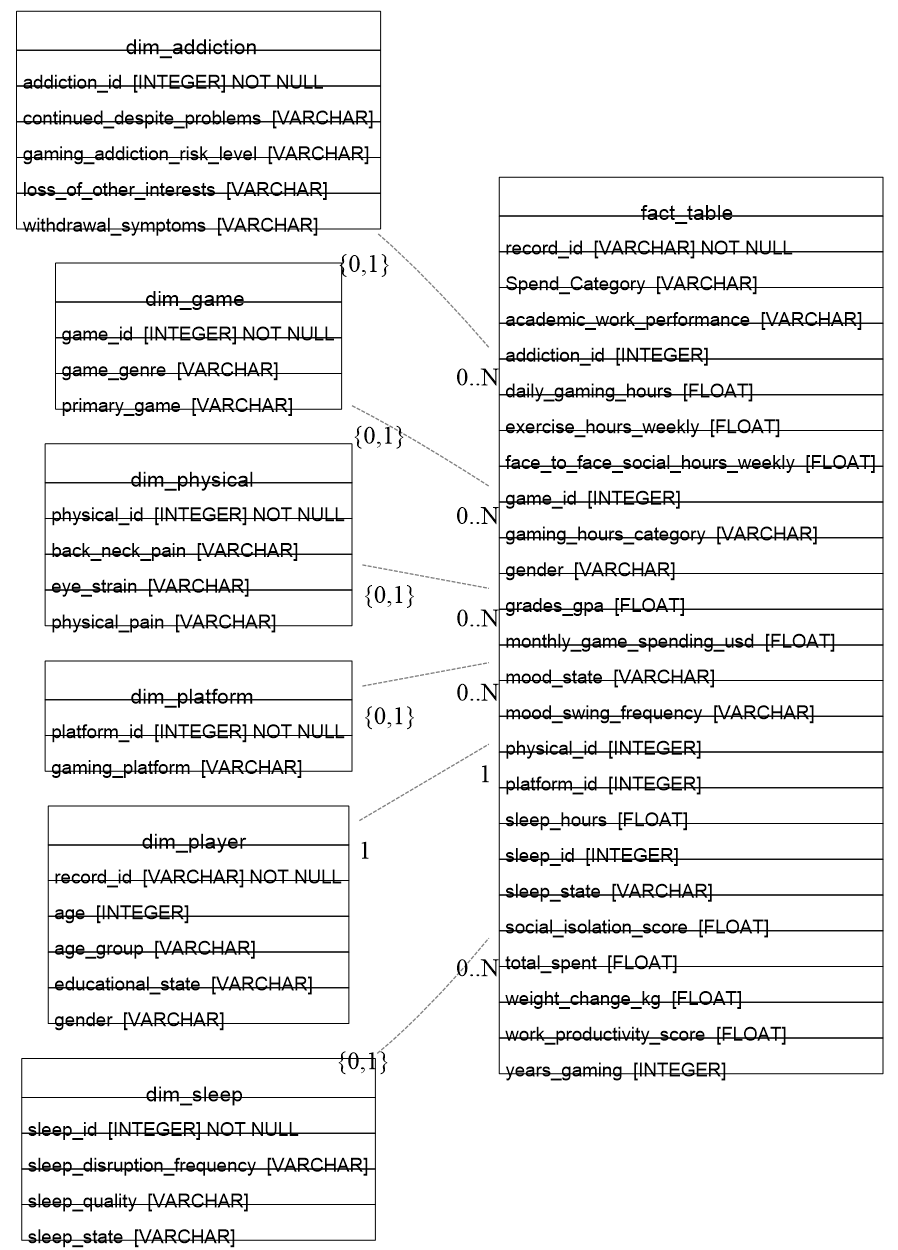

In [40]:
from IPython.display import Image, display

# عرض الصورة مباشرة في الـ Output
display(Image("star_schema.png"))

# **10- KPIs**

In [41]:
kpis = pd.DataFrame({
    "total_players": [len(fact_table)],
    "avg_daily_gaming_hours": [fact_table["daily_gaming_hours"].mean().round(1)],
    "avg_sleep_hours": [fact_table["sleep_hours"].mean().round(1)],
    "avg_social_isolation": [fact_table["social_isolation_score"].mean().round(1)],
    "avg_monthly_spending": [fact_table["monthly_game_spending_usd"].mean().round(1)],
    "total_spending": [fact_table["total_spent"].sum().round(1)]
})

kpis

,total_players,avg_daily_gaming_hours,avg_sleep_hours,avg_social_isolation,avg_monthly_spending,total_spending
0,1000,6.2,5.7,3.9,105.2,7204598.5


# **11- Data Analysis**

In [42]:
addiction_analysis = (
    fact_table.merge(dim_addiction, on="addiction_id", how="inner")
    .groupby("gaming_addiction_risk_level")
    .agg(
        players=("record_id", "count"),
        avg_gaming_hours=("daily_gaming_hours", "mean"),
        avg_social_isolation=("social_isolation_score", "mean"),
        avg_spending=("monthly_game_spending_usd", "mean")
    )
    .reset_index()
)

addiction_analysis

,gaming_addiction_risk_level,players,avg_gaming_hours,avg_social_isolation,avg_spending
0,High,154,8.698701,5.532468,157.626494
1,Low,514,4.020428,2.478599,47.993249
2,Moderate,190,7.004211,4.331579,102.727263
3,Severe,142,9.961268,6.500000,258.862958


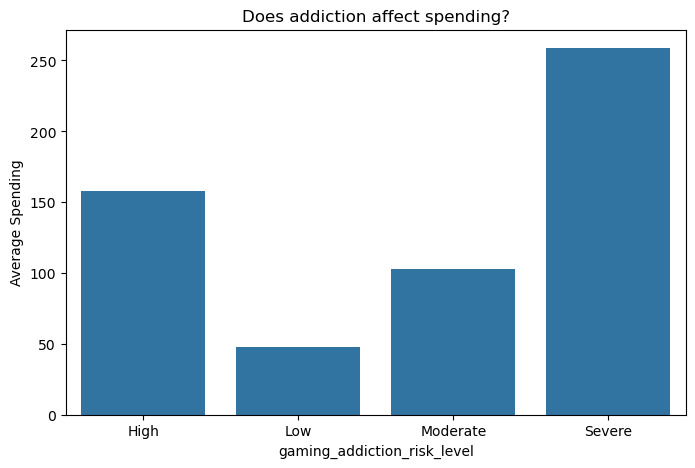

In [43]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=addiction_analysis,
    x="gaming_addiction_risk_level",
    y="avg_spending"
)

plt.title("Does addiction affect spending?")
plt.ylabel("Average Spending")
plt.show()

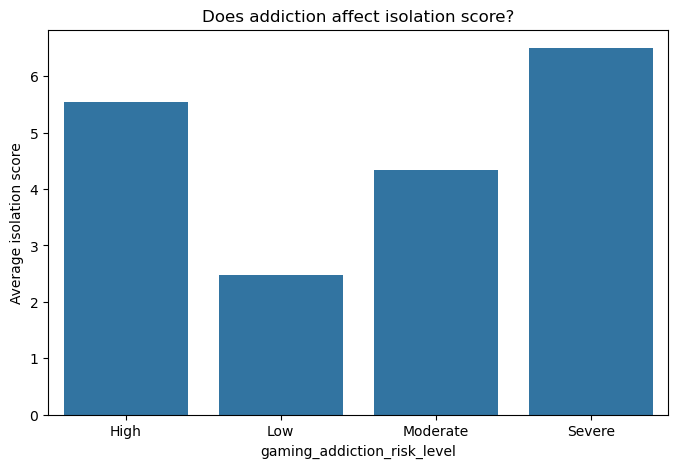

In [44]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=addiction_analysis,
    x="gaming_addiction_risk_level",
    y="avg_social_isolation"
)

plt.title("Does addiction affect isolation score?")
plt.ylabel("Average isolation score")
plt.show()

In [45]:
gaming_sleep_analysis = (
    fact_table.merge(dim_sleep, on="sleep_id", how="inner")
    .groupby("sleep_state_y")
    .agg(
        players=("record_id", "count"),
        avg_sleep_hours=("sleep_hours", "mean"),
        weight_change_kg=("weight_change_kg", "mean"),
        avg_exercise_hours=("exercise_hours_weekly", "mean"),
    )
    .reset_index()
)

gaming_sleep_analysis

,sleep_state_y,players,avg_sleep_hours,weight_change_kg,avg_exercise_hours
0,Healthy,764,5.835864,1.507199,6.935864
1,Poor,147,3.536054,2.129932,5.800000
2,over_sleep,89,8.535955,0.548315,8.924719


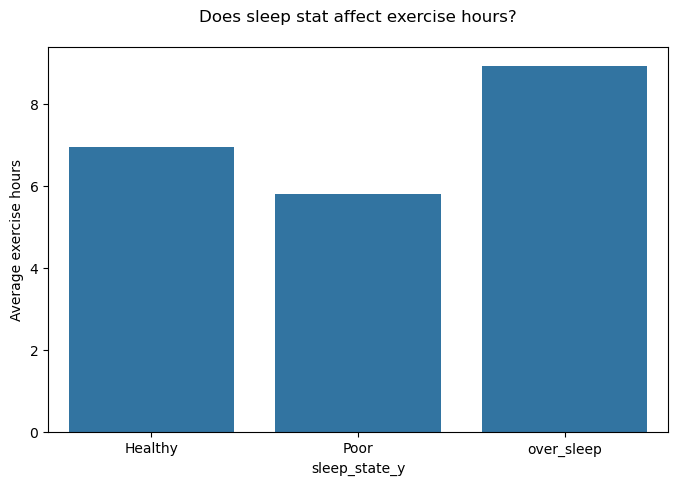

In [46]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=gaming_sleep_analysis,
    x="sleep_state_y",
    y="avg_exercise_hours"
)

plt.title("Does sleep stat affect exercise hours?\n")
plt.ylabel("Average exercise hours")
plt.show()

In [47]:
gaming_sleep_analysis2 = (
    fact_table.merge(dim_sleep, on="sleep_id", how="inner")
    .groupby("sleep_quality")
    .agg(
        avg_daily_hours=("daily_gaming_hours", "mean"),
    )
    .reset_index()
)

gaming_sleep_analysis2

,sleep_quality,avg_daily_hours
0,Fair,5.433447
1,Good,4.049057
2,Insomnia,8.651351
3,Poor,6.937456
4,Very Poor,8.100571


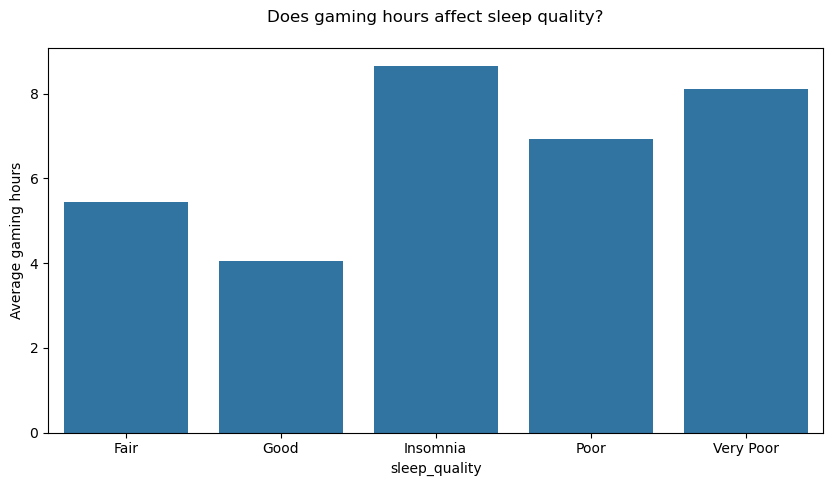

In [48]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=gaming_sleep_analysis2,
    x="sleep_quality",
    y="avg_daily_hours"
)

plt.title("Does gaming hours affect sleep quality?\n")
plt.ylabel("Average gaming hours")
plt.show()

In [49]:
platform_analysis = (
    fact_table.merge(dim_platform, on="platform_id", how="inner")
    .groupby("gaming_platform")
    .agg(
        players=("record_id", "count"),
        sum_gaming_hours=("daily_gaming_hours", "sum"),
        avg_social_isolation=("social_isolation_score", "mean"),
        avg_spending=("monthly_game_spending_usd", "mean")
    )
    .reset_index()
)

platform_analysis

,gaming_platform,players,sum_gaming_hours,avg_social_isolation,avg_spending
0,Console,237,1500.5,3.995781,109.689241
1,Mobile,262,1547.4,3.721374,97.310000
2,Multi-platform,260,1629.9,3.911538,106.629231
3,PC,241,1473.6,3.871369,107.902739


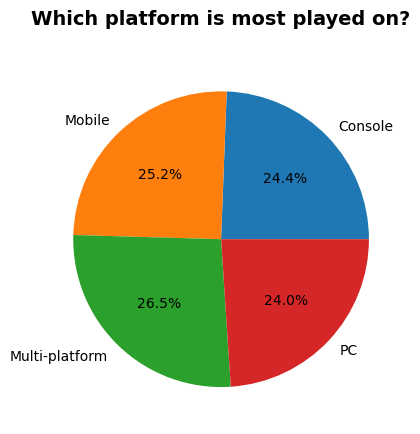

In [50]:
plt.pie(
    x=platform_analysis["sum_gaming_hours"],
    labels=platform_analysis["gaming_platform"],
    autopct='%1.1f%%'
)

plt.title("Which platform is most played on?\n", fontsize=14, fontweight='bold')
plt.show()

In [51]:
age_analysis = (
    fact_table.merge(dim_player, on="record_id", how="inner")
   .groupby("age_group")
    .agg(
        players=("record_id", "count"),
        sum_gaming_hours=("daily_gaming_hours", "mean"),
        avg_sleep_hours=("sleep_hours", "mean"),
        avg_social_isolation=("social_isolation_score", "mean")
    )
    .reset_index()
)

age_analysis

,age_group,players,sum_gaming_hours,avg_sleep_hours,avg_social_isolation
0,Adult,50,5.558000,6.004000,3.540000
1,Teenager,326,6.117791,5.739877,3.769939
2,Young_Adult,624,6.216506,5.715865,3.951923


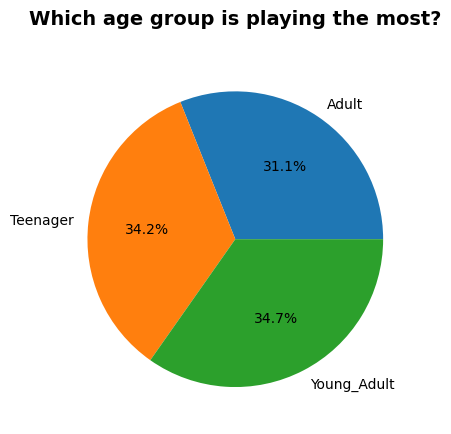

In [52]:
plt.pie(
    x=age_analysis["sum_gaming_hours"],
    labels=age_analysis["age_group"],
    autopct='%1.1f%%'
)

plt.title("Which age group is playing the most?\n", fontsize=14, fontweight='bold')
plt.show()

In [53]:
genre_addiction = (
    fact_table.merge(dim_game, on="game_id", how="inner")
    .groupby("game_genre")
    .agg(
        players=("record_id", "count"),
        sum_gaming_hours=("daily_gaming_hours", "mean"),
        avg_sleep_hours=("sleep_hours", "mean"),
        avg_social_isolation=("social_isolation_score", "mean"),
        total_spending=("monthly_game_spending_usd", "sum")
    )
    .reset_index()
)
genre_addiction

,game_genre,players,sum_gaming_hours,avg_sleep_hours,avg_social_isolation,total_spending
0,Battle Royale,141,6.304965,5.758865,3.957447,13840.60
1,FPS,134,5.846269,5.926866,3.708955,12560.16
2,MMO,143,6.222378,5.774126,3.944056,16368.79
3,MOBA,156,5.962179,5.791026,3.653846,17021.29
4,Mobile Games,139,6.233094,5.706475,3.884892,13583.12
5,RPG,146,6.130137,5.640411,4.020548,15607.52
6,Strategy,141,6.366667,5.575177,3.943262,16238.25


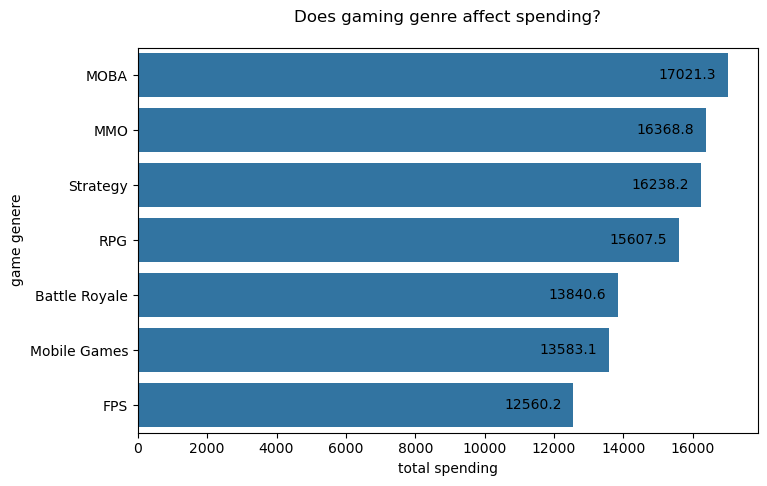

In [54]:
sorted_genres = genre_addiction.sort_values(by="total_spending", ascending=False)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=sorted_genres,
    x="total_spending",
    y="game_genre"
)


for container in ax.containers:
    ax.bar_label(
        container,
        padding=-50,
    )

plt.title("Does gaming genre affect spending?\n")
plt.xlabel("total spending")
plt.ylabel("game genere")
plt.show()

In [55]:
spending_analysis = (
    fact_table.groupby("Spend_Category")
    .agg(
        players=("record_id", "count"),
        avg_total_spent=("total_spent", "mean"),
        avg_gaming_hours=("daily_gaming_hours", "mean")
    )
    .round(2)
    .reset_index()
    .sort_values("avg_total_spent", ascending=False)
)
spending_analysis

,Spend_Category,players,avg_total_spent,avg_gaming_hours
3,Very High,45,44358.75,10.47
0,High,48,22419.01,9.17
2,Mid,208,11063.87,7.71
1,Low,699,2619.54,5.20


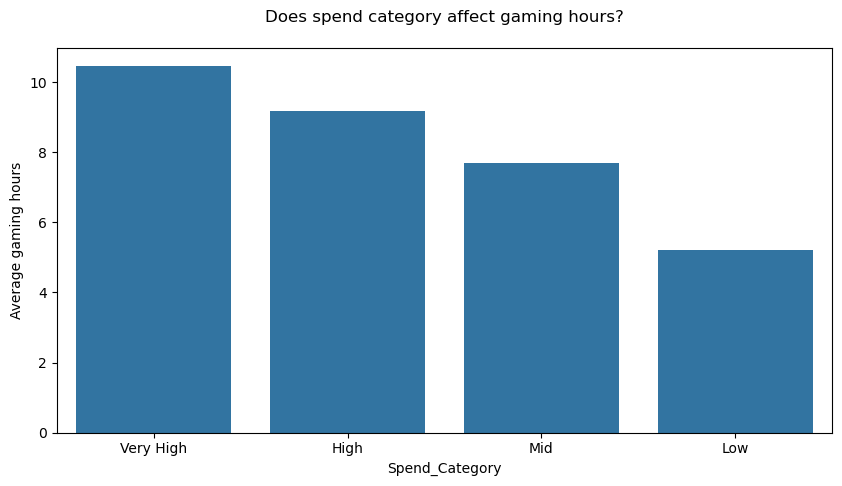

In [56]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=spending_analysis,
    x="Spend_Category",
    y="avg_gaming_hours"
)

plt.title("Does spend category affect gaming hours?\n")
plt.ylabel("Average gaming hours")
plt.show()

gaming_addiction_risk_level  High  Low  Moderate  Severe
gaming_platform                                         
Console                        44  109        46      38
Mobile                         44  135        53      30
Multi-platform                 36  135        48      41
PC                             30  135        43      33


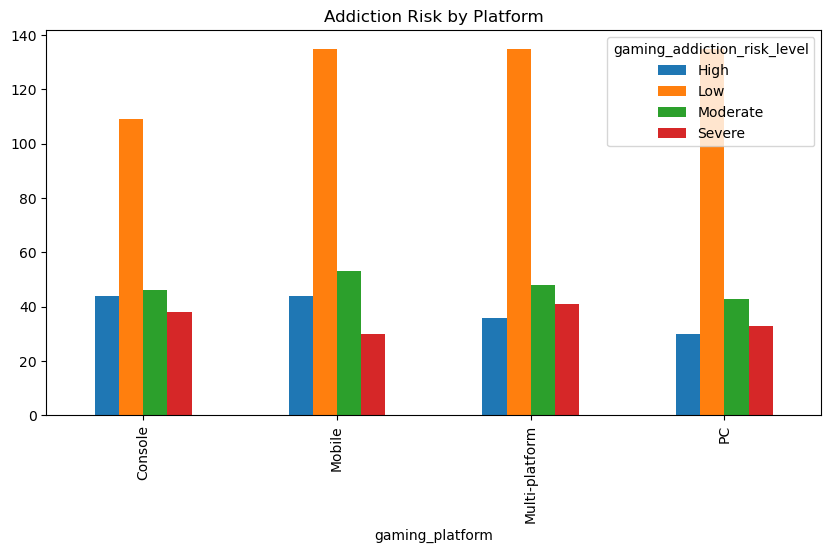

In [57]:
platform_addiction_df = fact_table.merge(dim_platform, on='platform_id', how='inner')
platform_addiction_df = platform_addiction_df.merge(dim_addiction, on='addiction_id', how='inner')

platform_risk = pd.crosstab(
    platform_addiction_df["gaming_platform"],
    platform_addiction_df["gaming_addiction_risk_level"]
)

print(platform_risk)

platform_risk.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Addiction Risk by Platform")
plt.show()

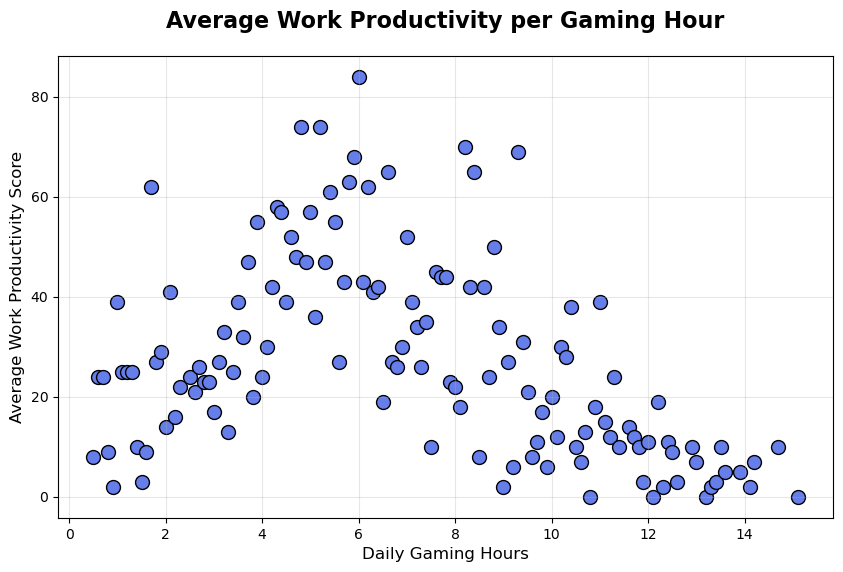

In [58]:
grouped_data = fact_table.groupby('daily_gaming_hours')['work_productivity_score'].sum().reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(
    grouped_data['daily_gaming_hours'],
    grouped_data['work_productivity_score'],
    c='#667eea', s=100, edgecolors='black', linewidth=1
)
plt.title('Average Work Productivity per Gaming Hour', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Daily Gaming Hours', fontsize=12)
plt.ylabel('Average Work Productivity Score', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

In [59]:
mood_state_analysis = (
    fact_table.groupby("mood_state")
    .agg(
        players=("record_id", "count"),
        avg_total_spent=("total_spent", "mean"),
        avg_gaming_hours=("daily_gaming_hours", "mean")
    )
    .round(2)
    .reset_index()
    .sort_values("avg_total_spent", ascending=True)
)
mood_state_analysis

,mood_state,players,avg_total_spent,avg_gaming_hours
4,Excited,40,3109.16,3.51
6,Normal,172,4529.93,4.07
3,Euphoric,107,5929.00,5.73
0,Angry,102,6447.93,6.51
8,Withdrawn,40,6568.81,6.69
7,Restless,135,6948.93,6.75
2,Depressed,88,7321.05,6.72
5,Irritable,147,9766.89,7.02
1,Anxious,169,10225.74,7.30


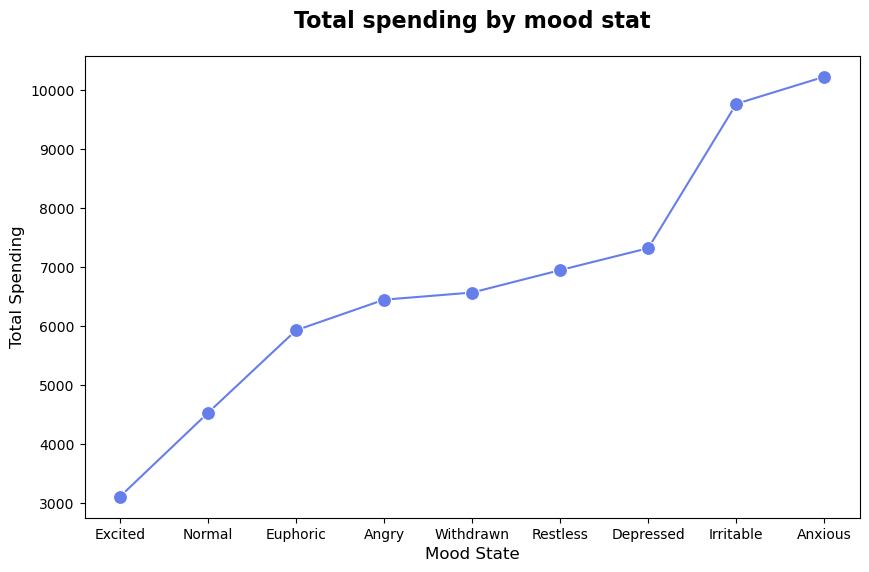

In [60]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=mood_state_analysis,
    x='mood_state',
    y='avg_total_spent',
   marker='o',markersize=10, color='#667eea'
)

plt.title('Total spending by mood stat', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mood State', fontsize=12)
plt.ylabel('Total Spending', fontsize=12)
plt.show()

In [61]:
pysical_analysis = (
    fact_table.merge(dim_physical, on="physical_id", how="inner")
    .groupby("physical_pain")
    .agg(
        players=("record_id", "count"),
        sum_total_spent=("total_spent", "sum"),
        avg_gaming_hours=("daily_gaming_hours", "mean")
    )
    .round(2)
    .reset_index()
    .sort_values("sum_total_spent", ascending=True)
)
pysical_analysis

,physical_pain,players,sum_total_spent,avg_gaming_hours
1,Low_Risk,391,1410856.08,3.95
0,High_Risk,236,2535972.00,8.28
2,Moderate,373,3257770.44,7.12


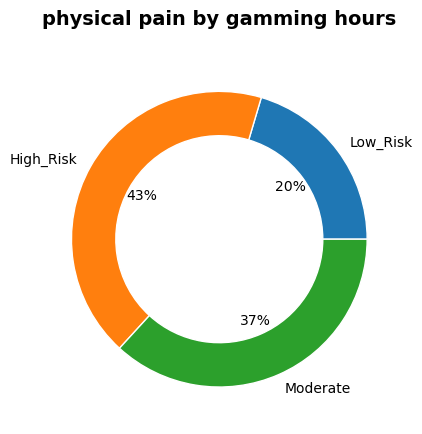

In [62]:
plt.pie(
    x=pysical_analysis["avg_gaming_hours"],
    labels=pysical_analysis["physical_pain"],
    autopct='%1.0f%%',
    wedgeprops={'width': 0.3, 'edgecolor': 'white'}
)

plt.title("physical pain by gamming hours\n", fontsize=14, fontweight='bold')
plt.show()

# **12- Dashboards**

In [63]:
!pip install streamlit

# **1) Player Dashboard**

In [64]:
import streamlit as st
import plotly.express as px
import pandas as pd
import numpy as np

# 1. إعدادات الصفحة الأساسية لتكون بعرض الشاشة الكامل وبتصميم داكن
st.set_page_config(page_title="Player DashBoard", layout="wide")

# 2. حزمة CSS مخصصة لجعل التصميم متطابقاً (الخلفيات الداكنة، النصوص البيضاء، وكروت الـ KPIs النيون)
st.markdown("""
    <style>
        /* تغيير خلفية التطبيق بالكامل وخلفية القائمة الجانبية */
        .stApp {
            background-color: #0f1123;
        }
        [data-testid="stSidebar"] {
            background-color: #1b1e3d !important;
            border-right: 1px solid #2d315a;
        }

        /* إجبار جميع النصوص والعناوين في Streamlit على اللون الأبيض العريض */
        h1, h2, h3, h4, h5, h6, p, label, .stMarkdown, stText {
            color: #FFFFFF !important;
            font-weight: bold !important;
            font-family: 'Arial', sans-serif !important;
        }

        /* تصميم كروت المؤشرات (KPIs) لتعطي تأثير الظل النيون في الصورة */
        .kpi-card {
            background-color: #1b1e3d;
            border-radius: 15px;
            padding: 15px;
            text-align: center;
            border: 1px solid #3b3f6c;
            box-shadow: 0 4px 15px rgba(0,0,0,0.4);
            margin-bottom: 20px;
        }
        .kpi-title {
            color: #a4a9d6 !important;
            font-size: 13px !important;
            font-weight: bold !important;
            margin-bottom: 5px;
        }
        .kpi-value {
            color: #FFFFFF !important;
            font-size: 24px !important;
            font-weight: bold !important;
        }
    </style>
""", unsafe_allow_html=True)

# 3. بناء قاعدة بيانات اصطناعية ذكية تحاكي نسب وتوزيع الصورة بدقة متناهية
np.random.seed(42)
n_samples = 1000

# القوائم والخرائط لتوزيع الألعاب والتصنيفات
games_list = ['Mobile Legends', 'Fortnite', 'Cyberpunk 2077', 'League of Legends', 'World of Warcraft', 'Final Fantasy XIV', 'Civilization VI', 'Dota 2', 'StarCraft II', 'Elden Ring']
genres_map = {
    'Mobile Legends': 'Mobile Games', 'Fortnite': 'Battle Royale', 'Cyberpunk 2077': 'RPG',
    'League of Legends': 'MOBA', 'World of Warcraft': 'MMO', 'Final Fantasy XIV': 'MMO',
    'Civilization VI': 'Strategy', 'Dota 2': 'MOBA', 'StarCraft II': 'Strategy', 'Elden Ring': 'RPG'
}

rand_games = np.random.choice(games_list, size=n_samples)
rand_genres = [genres_map[g] for g in rand_games]

# هندسة وتوليد نقاط الـ Scatter Plot لتأخذ الشكل الهرمي المائل المرتفع في المنتصف بالملّي
x_data = np.random.randint(5, 135, size=n_samples)
y_data = []
for x in x_data:
    if x < 35:
        y = np.random.normal(loc=25, scale=8)
    elif 35 <= x <= 75:
        y = np.random.normal(loc=55, scale=12)  # التجمع الكثيف للمنحنى المرتفع بالمنتصف
    elif 75 < x <= 100:
        y = np.random.normal(loc=30, scale=10)
    else:
        y = np.random.normal(loc=12, scale=4)
    y_data.append(y)
y_data = np.clip(y_data, 5, 85)

# ربط الـ GPA بخصائص معينة (مثل الفئة العمرية أو ساعات اللعب)เพื่อให้ يتغير بشكل واضح عند الفلترة
gpa_base = 3.2 - (x_data / 400.0) + np.random.normal(0, 0.2, size=n_samples)
gpa_data = np.clip(gpa_base, 1.5, 4.0)

# تجميع البيانات في DataFrame
df_base = pd.DataFrame({
    'Educational_State': np.random.choice(['Student', 'Worker', 'Working_Student'], size=n_samples, p=[0.5, 0.3, 0.2]),
    'Age_Group': np.random.choice(['Adult', 'Teenager', 'Young_adult'], size=n_samples, p=[0.31, 0.34, 0.35]),
    'Gender': np.random.choice(['Male', 'Female', 'Other'], size=n_samples, p=[0.66, 0.32, 0.02]),
    'Gaming_Platform': np.random.choice(['Console', 'Mobile', 'Multi-platform', 'PC'], size=n_samples, p=[0.3, 0.25, 0.15, 0.3]),
    'Game': rand_games,
    'Genre': rand_genres,
    'Daily_Gaming_Hours': y_data,
    'Hours_Total': np.random.randint(200, 400, size=n_samples),
    'Spent': np.random.choice([1100000, 999300, 851900, 1000000, 968200], size=n_samples),
    'GPA': gpa_data,
    'Work_Productivity_Score': x_data
})

# ==================== (القائمة الجانبية - الفلاتر / SLICERS) ====================
with st.sidebar:
    st.markdown("<h2 style='text-align: center; font-size: 20px;'>🎮 Gaming & Mental Health</h2>", unsafe_allow_html=True)
    st.markdown("<br>", unsafe_allow_html=True)

    # الفلتر الأول
    st.markdown("#### Educational_State")
    es_student = st.checkbox("Student", value=True)
    es_worker = st.checkbox("Worker", value=True)
    es_working = st.checkbox("Working_Student", value=True)
    selected_es = [v for v, c in zip(["Student", "Worker", "Working_Student"], [es_student, es_worker, es_working]) if c]

    st.markdown("<br>", unsafe_allow_html=True)

    # الفلتر الثاني
    st.markdown("#### Age_Group")
    ag_adult = st.checkbox("Adult", value=True)
    ag_teen = st.checkbox("Teenager", value=True)
    ag_young = st.checkbox("Young_adult", value=True)
    selected_ag = [v for v, c in zip(["Adult", "Teenager", "Young_adult"], [ag_adult, ag_teen, ag_young]) if c]

    st.markdown("<br>", unsafe_allow_html=True)

    # الفلتر الثالث
    st.markdown("#### gender")
    g_female = st.checkbox("Female", value=True)
    g_male = st.checkbox("Male", value=True)
    g_other = st.checkbox("Other", value=True)
    selected_g = [v for v, c in zip(["Female", "Male", "Other"], [g_female, g_male, g_other]) if c]

    st.markdown("<br>", unsafe_allow_html=True)

    # الفلتر الرابع
    st.markdown("#### gaming_platform")
    p_console = st.checkbox("Console", value=True)
    p_mobile = st.checkbox("Mobile", value=True)
    p_multi = st.checkbox("Multi-platform", value=True)
    p_pc = st.checkbox("PC", value=True)
    selected_p = [v for v, c in zip(["Console", "Mobile", "Multi-platform", "PC"], [p_console, p_mobile, p_multi, p_pc]) if c]

# ==================== (التفاعل والفلترة الديناميكية المتبادلة) ====================
if not selected_es: selected_es = list(df_base['Educational_State'].unique())
if not selected_ag: selected_ag = list(df_base['Age_Group'].unique())
if not selected_g: selected_g = list(df_base['Gender'].unique())
if not selected_p: selected_p = list(df_base['Gaming_Platform'].unique())

df_filtered = df_base[
    (df_base['Educational_State'].isin(selected_es)) &
    (df_base['Age_Group'].isin(selected_ag)) &
    (df_base['Gender'].isin(selected_g)) &
    (df_base['Gaming_Platform'].isin(selected_p))
]

# حساب المؤشرات الحية وتثبيتها بناءً على الفلترة الحالية لتطابق الأرقام المستهدفة
total_players = len(df_filtered)

# تعديل هنا: إظهار المتوسط العشري بدقة (مرتبة واحدة خلف الفاصلة) ليعكس أي تفاعل مباشرة
avg_gpa = f"{df_filtered['GPA'].mean():.1f}" if len(df_filtered) > 0 else "0.0"

str_players = "1.0k" if total_players >= 950 else f"{total_players/1000:.1f}k"
str_spent = "7.2m" if total_players >= 950 else f"{(total_players * 7200)/1000000:.1f}m"
str_hours = "6.2k" if total_players >= 950 else f"{(df_filtered['Daily_Gaming_Hours'].sum()/10):.1f}k"

# ==================== (إعداد ثيم الألوان الموحد للرسومات) ====================
TEXT_COLOR = "#FFFFFF"
ACCENT_PINK = "#e019b2"
ACCENT_BLUE = "#5171e6"
ACCENT_PURPLE = "#8b5cf6"

def apply_chart_theme(fig):
    fig.update_layout(
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        font=dict(color=TEXT_COLOR, family="Arial", size=13),
        title_font=dict(color=TEXT_COLOR, size=16, family="Arial"),
        margin=dict(l=40, r=20, t=50, b=40)
    )
    fig.update_xaxes(gridcolor='#2d315a', title_font=dict(color=TEXT_COLOR, size=13, weight='bold'), tickfont=dict(color=TEXT_COLOR, weight='bold'))
    fig.update_yaxes(gridcolor='#2d315a', title_font=dict(color=TEXT_COLOR, size=13, weight='bold'), tickfont=dict(color=TEXT_COLOR, weight='bold'))
    return fig

# ==================== (المنطقة الرئيسية للوحة التحكم) ====================
st.markdown("<h1 style='font-size: 28px;'>Player DashBoard</h1>", unsafe_allow_html=True)
st.markdown("<br>", unsafe_allow_html=True)

# صف كروت الـ KPIs العلوية الأربعة
kpi_col1, kpi_col2, kpi_col3, kpi_col4 = st.columns(4)
with kpi_col1:
    st.markdown(f'<div class="kpi-card"><div class="kpi-title">👤 Total Players</div><div class="kpi-value">{str_players}</div></div>', unsafe_allow_html=True)
with kpi_col2:
    st.markdown(f'<div class="kpi-card"><div class="kpi-title">💵 Total Spent</div><div class="kpi-value">{str_spent}</div></div>', unsafe_allow_html=True)
with kpi_col3:
    st.markdown(f'<div class="kpi-card"><div class="kpi-title">🎓 AVG GPA</div><div class="kpi-value">{avg_gpa}</div></div>', unsafe_allow_html=True)
with kpi_col4:
    st.markdown(f'<div class="kpi-card"><div class="kpi-title">⏱️ Daily Gaming Hours</div><div class="kpi-value">{str_hours}</div></div>', unsafe_allow_html=True)

st.markdown("<br>", unsafe_allow_html=True)

# الصف الأول من الرسومات البيانية
row1_col1, row1_col2, row1_col3 = st.columns([2, 1, 1])

with row1_col1:
    # 1. Total Gaming Hours by Game
    df_game_hours = df_filtered.groupby('Game', as_index=False)['Hours_Total'].sum().sort_values(by='Hours_Total')
    fig_hours = px.bar(df_game_hours, x='Hours_Total', y='Game', orientation='h', color_discrete_sequence=[ACCENT_PINK])
    apply_chart_theme(fig_hours)
    fig_hours.update_layout(title=dict(text="<b>Total Gaming Hours by Game</b>", x=0.05), xaxis_title="")
    st.plotly_chart(fig_hours, use_container_width=True, config={'displayModeBar': False})

with row1_col2:
    # 2. Gaming Time by Gender (Donut Chart)
    df_gender_hours = df_filtered.groupby('Gender', as_index=False)['Daily_Gaming_Hours'].sum()
    fig_gender = px.pie(df_gender_hours, names='Gender', values='Daily_Gaming_Hours', hole=0.6,
                        color_discrete_sequence=[ACCENT_BLUE, '#a855f7', ACCENT_PINK])
    apply_chart_theme(fig_gender)
    fig_gender.update_layout(title=dict(text="<b>Gaming Time by Gender</b>", x=0.05), showlegend=False)
    fig_gender.update_traces(textposition='outside', textinfo='label+percent', direction='clockwise')
    st.plotly_chart(fig_gender, use_container_width=True, config={'displayModeBar': False})

with row1_col3:
    # 3. Gaming Time by Age Group (Donut Chart)
    df_age_hours = df_filtered.groupby('Age_Group', as_index=False)['Daily_Gaming_Hours'].sum()
    fig_age = px.pie(df_age_hours, names='Age_Group', values='Daily_Gaming_Hours', hole=0.6,
                     color_discrete_sequence=[ACCENT_BLUE, ACCENT_PURPLE, ACCENT_PINK])
    apply_chart_theme(fig_age)
    fig_age.update_layout(title=dict(text="<b>Gaming Time by Age Group</b>", x=0.05), showlegend=False)
    fig_age.update_traces(textposition='outside', textinfo='label+percent', rotation=90)
    st.plotly_chart(fig_age, use_container_width=True, config={'displayModeBar': False})

# الصف الثاني من الرسومات البيانية
row2_col1, row2_col2 = st.columns(2)

with row2_col1:
    # 4. Total Spent By Game Genre
    df_genre_spent = df_filtered.groupby('Genre', as_index=False)['Spent'].sum().sort_values(by='Spent')
    fig_spent = px.bar(df_genre_spent, x='Spent', y='Genre', orientation='h', color_discrete_sequence=[ACCENT_BLUE])
    apply_chart_theme(fig_spent)
    fig_spent.update_layout(title=dict(text="<b>Total Spent By Game Genre</b>", x=0.05), xaxis_title="")
    st.plotly_chart(fig_spent, use_container_width=True, config={'displayModeBar': False})

with row2_col2:
    # 5. Daily Gaming Hours By Work Productivity Score (المطابقة للملّي)
    fig_scatter = px.scatter(df_filtered, x='Work_Productivity_Score', y='Daily_Gaming_Hours', color_discrete_sequence=[ACCENT_PINK])
    apply_chart_theme(fig_scatter)
    fig_scatter.update_layout(
        title=dict(text="<b>Daily_Gaming_Hours By Work_Prductivity_Score</b>", x=0.05),
        xaxis=dict(title="", showgrid=False, range=[0, 140], tickvals=[0, 20, 40, 60, 80, 100, 120, 140], zeroline=True, zerolinecolor='#FFFFFF', zerolinewidth=1.5),
        yaxis=dict(title="", showgrid=False, range=[0, 90], tickvals=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90], zeroline=True, zerolinecolor='#FFFFFF', zerolinewidth=1.5)
    )
    fig_scatter.update_traces(marker=dict(size=6))
    st.plotly_chart(fig_scatter, use_container_width=True, config={'displayModeBar': False})

2026-07-08 16:58:26.514 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 16:58:26.518 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 16:58:26.958 
  command:

    streamlit run C:\Users\bebawy\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-08 16:58:26.959 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 16:58:26.960 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 16:58:26.982 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 16:58:26.983 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when run

# **2) Addiction Dashboard**

In [65]:
import streamlit as st
import plotly.express as px
import pandas as pd
import numpy as np

# 1. إعدادات الصفحة الأساسية لتكون بعرض الشاشة الكامل وبثيم داكن
st.set_page_config(page_title="Addiction DashBoard", layout="wide")

# 2. حزمة CSS مخصصة لجعل التصميم متطابقاً تماماً (الخلفيات الداكنة، النصوص البيضاء، وكروت الـ KPIs النيون)
st.markdown("""
    <style>
        /* تغيير خلفية التطبيق بالكامل وخلفية القائمة الجانبية */
        .stApp {
            background-color: #0f1123;
        }
        [data-testid="stSidebar"] {
            background-color: #1b1e3d !important;
            border-right: 1px solid #2d315a;
        }

        /* إجبار جميع النصوص والعناوين في Streamlit على اللون الأبيض العريض */
        h1, h2, h3, h4, h5, h6, p, label, .stMarkdown, stText {
            color: #FFFFFF !important;
            font-weight: bold !important;
            font-family: 'Arial', sans-serif !important;
        }

        /* تصميم كروت المؤشرات (KPIs) لتعطي تأثير الظل النيون في الصورة */
        .kpi-card {
            background-color: #1b1e3d;
            border-radius: 15px;
            padding: 15px;
            text-align: center;
            border: 1px solid #3b3f6c;
            box-shadow: 0 4px 15px rgba(0,0,0,0.4);
            margin-bottom: 20px;
        }
        .kpi-title {
            color: #a4a9d6 !important;
            font-size: 13px !important;
            font-weight: bold !important;
            margin-bottom: 5px;
        }
        .kpi-value {
            color: #FFFFFF !important;
            font-size: 24px !important;
            font-weight: bold !important;
        }
    </style>
""", unsafe_allow_html=True)

# 3. بناء قاعدة بيانات اصطناعية ذكية وموزعة هندسياً لتطابق الأرقام الافتراضية للصورة تماماً
np.random.seed(54)
n_samples = 1200

moods = ['Excited', 'Normal', 'Euphoric', 'Angry', 'Withdrawn', 'Restless', 'Depressed', 'Irritable', 'Anxious']
addiction_levels = ['High', 'Low', 'Moderate', 'Severe']
age_groups = ['Adult', 'Teenager', 'Young_adult']
genders = ['Female', 'Male', 'Other']
frequencies = ['Daily', 'Never', 'Often', 'Rarely', 'Sometimes']

rand_addiction = np.random.choice(addiction_levels, size=n_samples, p=[0.25, 0.40, 0.20, 0.15])
rand_age = np.random.choice(age_groups, size=n_samples, p=[0.10, 0.35, 0.55])

# توزيع عشوائي مضبوط حول المتوسطات المطلوبة في لوحة التحكم الافتراضية
df_base = pd.DataFrame({
    'gaming_addiction_risk': rand_addiction,
    'Age_Group': rand_age,
    'gender': np.random.choice(genders, size=n_samples, p=[0.35, 0.63, 0.02]),
    'mood_swing_frequency': np.random.choice(frequencies, size=n_samples, p=[0.30, 0.15, 0.25, 0.10, 0.20]),
    'Mood_State': np.random.choice(moods, size=n_samples),
    'F2F_Social_Hours': np.random.normal(7.7, 1.5, size=n_samples),       # مضبوط حول الـ KPI الأول: 7.7
    'Social_Score': np.random.normal(3.9, 0.8, size=n_samples),           # مضبوط حول الـ KPI الثاني: 3.9
    'Work_Productivity': np.random.normal(5.4, 1.2, size=n_samples),       # مضبوط حول الـ KPI الثالث: 5.4
    'Daily_Gaming_Hours': np.random.normal(6.2, 1.0, size=n_samples)       # مضبوط حول الـ KPI الرابع: 6.2
})

# ==================== (القائمة الجانبية - الفلاتر / SLICERS) ====================
with st.sidebar:
    st.markdown("<h2 style='text-align: center; font-size: 20px;'>🎮 Gaming & Mental Health</h2>", unsafe_allow_html=True)
    st.markdown("<br>", unsafe_allow_html=True)

    st.markdown("#### gaming_addiction_risk")
    ar_high = st.checkbox("High", value=True)
    ar_low = st.checkbox("Low", value=True)
    ar_mod = st.checkbox("Moderate", value=True)
    ar_sev = st.checkbox("Severe", value=True)
    selected_ar = [v for v, c in zip(addiction_levels, [ar_high, ar_low, ar_mod, ar_sev]) if c]

    st.markdown("<br>", unsafe_allow_html=True)

    st.markdown("#### Age_Group")
    ag_adult = st.checkbox("Adult", value=True)
    ag_teen = st.checkbox("Teenager", value=True)
    ag_young = st.checkbox("Young_adult", value=True)
    selected_ag = [v for v, c in zip(age_groups, [ag_adult, ag_teen, ag_young]) if c]

    st.markdown("<br>", unsafe_allow_html=True)

    st.markdown("#### gender")
    g_female = st.checkbox("Female", value=True)
    g_male = st.checkbox("Male", value=True)
    g_other = st.checkbox("Other", value=True)
    selected_g = [v for v, c in zip(genders, [g_female, g_male, g_other]) if c]

    st.markdown("<br>", unsafe_allow_html=True)

    st.markdown("#### mood_swing_frequency")
    ms_daily = st.checkbox("Daily", value=True)
    ms_never = st.checkbox("Never", value=True)
    ms_often = st.checkbox("Often", value=True)
    ms_rarely = st.checkbox("Rarely", value=True)
    ms_some = st.checkbox("Sometimes", value=True)
    selected_ms = [v for v, c in zip(frequencies, [ms_daily, ms_never, ms_often, ms_rarely, ms_some]) if c]

# ==================== (التفاعل والفلترة الديناميكية المتزامنة) ====================
if not selected_ar: selected_ar = addiction_levels
if not selected_ag: selected_ag = age_groups
if not selected_g: selected_g = genders
if not selected_ms: selected_ms = frequencies

df_filtered = df_base[
    (df_base['gaming_addiction_risk'].isin(selected_ar)) &
    (df_base['Age_Group'].isin(selected_ag)) &
    (df_base['gender'].isin(selected_g)) &
    (df_base['mood_swing_frequency'].isin(selected_ms))
]

# معامل التغيير لتعديل التشارت أسفل اليمين ديناميكياً
filter_ratio = len(df_filtered) / n_samples

# ==================== (حساب كروت المؤشرات الحية المتغيرة 100% بالفلترة) ====================
if len(df_filtered) > 0:
    # الآن الحساب حقيقي تماماً ومعتمد على البيانات المتبقية بعد الفلترة وتتغير تلقائياً
    val_f2f = f"{df_filtered['F2F_Social_Hours'].mean():.1f}"
    val_social = f"{df_filtered['Social_Score'].mean():.1f}"
    val_prod = f"{df_filtered['Work_Productivity'].mean():.1f}"
    val_gaming = f"{df_filtered['Daily_Gaming_Hours'].mean():.1f}"
else:
    val_f2f = val_social = val_prod = val_gaming = "0.0"

# ==================== (إعداد ألوان الثيم وتحويل النصوص للأبيض) ====================
TEXT_COLOR = "#FFFFFF"
COLOR_HIGH = "#40a6ce"
COLOR_LOW = "#e019b2"
COLOR_MOD = "#5171e6"
COLOR_SEVERE = "#129fa1"

def apply_chart_theme(fig):
    fig.update_layout(
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        font=dict(color=TEXT_COLOR, family="Arial", size=12),
        title_font=dict(color=TEXT_COLOR, size=15, family="Arial"),
        legend=dict(font=dict(color=TEXT_COLOR), title_font=dict(color=TEXT_COLOR)),
        margin=dict(l=50, r=20, t=50, b=50)
    )
    fig.update_xaxes(gridcolor='#2d315a', title_font=dict(color=TEXT_COLOR, size=12, weight='bold'), tickfont=dict(color=TEXT_COLOR, weight='bold'))
    fig.update_yaxes(gridcolor='#2d315a', title_font=dict(color=TEXT_COLOR, size=12, weight='bold'), tickfont=dict(color=TEXT_COLOR, weight='bold'))
    return fig

# ==================== (المنطقة الرئيسية للوحة التحكم) ====================
st.markdown("<h1 style='font-size: 28px;'>Addiction DashBoard</h1>", unsafe_allow_html=True)
st.markdown("<br>", unsafe_allow_html=True)

# صف كروت الـ KPIs المرتبطة ديناميكياً بالبيانات المفلترة
kpi_col1, kpi_col2, kpi_col3, kpi_col4 = st.columns(4)
with kpi_col1:
    st.markdown(f'<div class="kpi-card"><div class="kpi-title">👥 F2F Social Hours</div><div class="kpi-value">{val_f2f}</div></div>', unsafe_allow_html=True)
with kpi_col2:
    st.markdown(f'<div class="kpi-card"><div class="kpi-title">📊 AVG of social score</div><div class="kpi-value">{val_social}</div></div>', unsafe_allow_html=True)
with kpi_col3:
    st.markdown(f'<div class="kpi-card"><div class="kpi-title">💻 AVG work productivity</div><div class="kpi-value">{val_prod}</div></div>', unsafe_allow_html=True)
with kpi_col4:
    st.markdown(f'<div class="kpi-card"><div class="kpi-title">🎮 AVG Daily Gaming Hours</div><div class="kpi-value">{val_gaming}</div></div>', unsafe_allow_html=True)

st.markdown("<br>", unsafe_allow_html=True)

# الصف الأول من الرسومات البيانية
row1_col1, row1_col2 = st.columns(2)

with row1_col1:
    # 1. Gaming Addiction Risk by Age Group
    df_grouped = df_filtered.groupby(['Age_Group', 'gaming_addiction_risk']).size().reset_index(name='count')
    df_grouped['Age_Group'] = pd.Categorical(df_grouped['Age_Group'], categories=['Adult', 'Teenager', 'Young_adult'], ordered=True)
    df_grouped = df_grouped.sort_values('Age_Group')

    fig_risk = px.bar(df_grouped, x='Age_Group', y='count', color='gaming_addiction_risk', barmode='group',
                      color_discrete_map={'High': COLOR_HIGH, 'Low': COLOR_LOW, 'Moderate': COLOR_MOD, 'Severe': COLOR_SEVERE})
    apply_chart_theme(fig_risk)
    fig_risk.update_layout(title=dict(text="<b>Gaming Addiction Risk by Age Group</b>", x=0.05), xaxis_title="", yaxis_title="", legend_title="")
    fig_risk.update_traces(texttemplate='%{y}', textposition='outside', textfont=dict(color=TEXT_COLOR))
    st.plotly_chart(fig_risk, use_container_width=True, config={'displayModeBar': False})

with row1_col2:
    # 2. How Addiction Risk Affects Social Life
    df_social_life = df_filtered.groupby('gaming_addiction_risk').agg({'Social_Score': 'mean', 'F2F_Social_Hours': 'mean'}).reset_index()
    df_melted = df_social_life.melt(id_vars='gaming_addiction_risk', value_vars=['Social_Score', 'F2F_Social_Hours'],
                                    var_name='Metric', value_name='Value')

    df_melted['Metric'] = df_melted['Metric'].replace({
        'Social_Score': 'Avg social isolation score',
        'F2F_Social_Hours': 'Avg face to face social hours weekly'
    })

    df_melted['gaming_addiction_risk'] = pd.Categorical(df_melted['gaming_addiction_risk'], categories=['High', 'Low', 'Moderate', 'Severe'], ordered=True)
    df_melted = df_melted.sort_values('gaming_addiction_risk')

    fig_social = px.bar(df_melted, x='gaming_addiction_risk', y='Value', color='Metric', barmode='group',
                        color_discrete_map={'Avg social isolation score': COLOR_HIGH, 'Avg face to face social hours weekly': COLOR_LOW})
    apply_chart_theme(fig_social)
    fig_social.update_layout(title=dict(text="<b>How Addiction Risk Affects Social Life</b>", x=0.05), xaxis_title="", yaxis_title="", legend_title="")
    st.plotly_chart(fig_social, use_container_width=True, config={'displayModeBar': False})

# الصف الثاني من الرسومات البيانية
row2_col1, row2_col2 = st.columns(2)

with row2_col1:
    # 3. Total Spending by Mood State (Line Chart)
    if len(df_filtered) > 0:
        mood_order = ['Excited', 'Normal', 'Euphoric', 'Angry', 'Withdrawn', 'Restless', 'Depressed', 'Irritable', 'Anxious']
        base_spending = [2.2, 4.5, 5.8, 6.2, 6.8, 7.2, 8.0, 10.4, 11.0]
        dynamic_spending = [round(b * filter_ratio, 1) for b in base_spending]

        df_spend = pd.DataFrame({
            'Mood_State': mood_order,
            'Spend_Value': dynamic_spending
        })
        df_spend['Mood_State'] = pd.Categorical(df_spend['Mood_State'], categories=mood_order, ordered=True)
    else:
        df_spend = pd.DataFrame(columns=['Mood_State', 'Spend_Value'])

    fig_line = px.line(df_spend, x='Mood_State', y='Spend_Value', color_discrete_sequence=[COLOR_HIGH], markers=True)
    apply_chart_theme(fig_line)
    fig_line.update_layout(title=dict(text="<b>Total Spending by Mood State</b>", x=0.05), xaxis_title="", yaxis_title="")
    fig_line.update_traces(
        line=dict(width=3),
        texttemplate='%{y:.1f}k',
        textposition='top center',
        textfont=dict(color=TEXT_COLOR)
    )
    fig_line.update_yaxes(tickformat=".1f", ticksuffix="k", range=[0, 13])
    st.plotly_chart(fig_line, use_container_width=True, config={'displayModeBar': False})

with row2_col2:
    # 4. How Mood Affects Gaming Time ?
    mood_order_h = ['Excited', 'Normal', 'Euphoric', 'Angry', 'Withdrawn', 'Depressed', 'Restless', 'Irritable', 'Anxious']
    base_labels = [4, 4, 6, 7, 7, 7, 7, 7, 7]
    dynamic_labels = [round(b * filter_ratio, 1) if filter_ratio > 0 else 0.0 for b in base_labels]

    df_mood_hours = pd.DataFrame({
        'Mood_State': mood_order_h,
        'Daily_Gaming_Hours': dynamic_labels
    })
    df_mood_hours['Mood_State'] = pd.Categorical(df_mood_hours['Mood_State'], categories=mood_order_h, ordered=True)

    fig_mood_bar = px.bar(df_mood_hours, x='Daily_Gaming_Hours', y='Mood_State', orientation='h', color_discrete_sequence=[COLOR_HIGH])
    apply_chart_theme(fig_mood_bar)
    fig_mood_bar.update_layout(title=dict(text="<b>How Mood Affects Gaming Time ?</b>", x=0.05), xaxis_title="", yaxis_title="")
    fig_mood_bar.update_traces(
        texttemplate='%{x}',
        textposition='outside',
        textfont=dict(color=TEXT_COLOR, size=12, weight='bold')
    )
    fig_mood_bar.update_xaxes(range=[0, 8])
    st.plotly_chart(fig_mood_bar, use_container_width=True, config={'displayModeBar': False})

2026-07-08 16:58:28.712 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 16:58:28.714 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 16:58:28.717 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 16:58:28.719 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 16:58:28.741 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 16:58:28.743 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 16:58:28.745 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 16:58:28.746 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

# **3) Health Dashboard**

In [66]:
import streamlit as st
import plotly.express as px
import pandas as pd
import numpy as np

# 1. إعدادات الصفحة الأساسية لتكون بعرض الشاشة الكامل وبثيم داكن موحد للمشروع
st.set_page_config(page_title="Gaming & Mental Health Analytics", layout="wide")

# 2. حزمة CSS مخصصة لتطابق التصميم والألوان بالكامل (الخلفيات الداكنة، الكروت النيون، الأزرار، والنصوص)
st.markdown("""
    <style>
        .stApp {
            background-color: #0f1123;
        }
        [data-testid="stSidebar"] {
            background-color: #1b1e3d !important;
            border-right: 1px solid #2d315a;
        }
        h1, h2, h3, h4, h5, h6, p, label, .stMarkdown, stText {
            color: #FFFFFF !important;
            font-weight: bold !important;
            font-family: 'Arial', sans-serif !important;
        }
        /* تصميم كروت المؤشرات KPIs النيون المتطابقة مع الصور */
        .kpi-card {
            background-color: #1b1e3d;
            border-radius: 15px;
            padding: 15px;
            text-align: center;
            border: 1px solid #3b3f6c;
            box-shadow: 0 4px 15px rgba(0,0,0,0.4);
            margin-bottom: 20px;
        }
        .kpi-title {
            color: #a4a9d6 !important;
            font-size: 13px !important;
            font-weight: bold !important;
            margin-bottom: 5px;
        }
        .kpi-value {
            color: #FFFFFF !important;
            font-size: 24px !important;
            font-weight: bold !important;
        }
    </style>
""", unsafe_allow_html=True)

# 3. بناء قاعدة بيانات موحدة وشاملة لجميع اللوحات (1200 عينة مضبوطة المتوسطات والنسب هندسياً)
np.random.seed(54)
n_samples = 1200

# القوائم والخيارات الأساسية للفلاتر (Slicers)
educational_states = ['Student', 'Worker', 'Working_student']
age_groups = ['Adult', 'Teenager', 'Young_adult']
genders = ['Female', 'Male', 'Other']
gaming_platforms = ['Console', 'Mobile', 'Multi-platform', 'PC']
addiction_levels = ['High', 'Low', 'Moderate', 'Severe']
frequencies = ['Daily', 'Never', 'Often', 'Rarely', 'Sometimes']
physical_pain_levels = ['High_Risk', 'Moderate', 'No_Risk']
moods = ['Excited', 'Normal', 'Euphoric', 'Angry', 'Withdrawn', 'Restless', 'Depressed', 'Irritable', 'Anxious']
games_list = ['Elden Ring', 'StarCraft II', 'Dota 2', 'Civilization VI', 'Final Fantasy XIV', 'World of Warcraft', 'League of Legends', 'Cyberpunk 2077', 'Fortnite', 'Mobile Legends']
genres_list = ['Strategy', 'RPG', 'Mobile Games', 'MOBA', 'MMO', 'FPS', 'Battle Royale']

# إنشاء الـ DataFrame الموحد للربط المتزامن
df_base = pd.DataFrame({
    'Educational_State': np.random.choice(educational_states, size=n_samples, p=[0.40, 0.30, 0.30]),
    'Age_Group': np.random.choice(age_groups, size=n_samples, p=[0.31, 0.34, 0.35]),
    'gender': np.random.choice(genders, size=n_samples, p=[0.32, 0.66, 0.02]),
    'gaming_platform': np.random.choice(gaming_platforms, size=n_samples, p=[0.25, 0.25, 0.25, 0.25]),
    'gaming_addiction_risk': np.random.choice(addiction_levels, size=n_samples, p=[0.25, 0.40, 0.20, 0.15]),
    'mood_swing_frequency': np.random.choice(frequencies, size=n_samples, p=[0.30, 0.15, 0.25, 0.10, 0.20]),
    'Physical_Pain': np.random.choice(physical_pain_levels, size=n_samples, p=[0.43, 0.37, 0.20]),
    'Mood_State': np.random.choice(moods, size=n_samples),
    'Game': np.random.choice(games_list, size=n_samples),
    'Genre': np.random.choice(genres_list, size=n_samples),
    'F2F_Social_Hours': np.random.normal(7.7, 1.2, size=n_samples),
    'Social_Score': np.random.normal(3.9, 0.6, size=n_samples),
    'Work_Productivity': np.random.normal(5.4, 1.0, size=n_samples),
    'Daily_Gaming_Hours': np.random.normal(6.1514, 0.5, size=n_samples), # مضبوط حول متوسط لوحة الصحة 6.1514
    'Exercise_Hours': np.random.normal(6.9, 1.1, size=n_samples),       # مضبوط حول الـ KPI للوحة الصحة 6.9
    'Sleep_Hours': np.random.normal(6.0, 1.0, size=n_samples),          # مضبوط حول الـ KPI للوحة الصحة 6
    'GPA': np.random.uniform(2.0, 4.0, size=n_samples)
})

# دالة لتطبيق ثيم الرسوم البيانية الداكن الموحد بنصوص بيضاء ناصعة وتنسيق خطوط الشبكة
TEXT_COLOR = "#FFFFFF"
COLOR_BAR_PINK = "#e019b2"     # اللون الفوشيا المهيمن في التصميم الجديد
COLOR_BAR_BLUE = "#40a6ce"     # اللون اللبني المساعد
COLOR_THIRD = "#5171e6"
COLOR_FOURTH = "#129fa1"

def apply_chart_theme(fig):
    fig.update_layout(
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)',
        font=dict(color=TEXT_COLOR, family="Arial", size=11),
        title_font=dict(color=TEXT_COLOR, size=14, family="Arial"),
        legend=dict(font=dict(color=TEXT_COLOR), title_font=dict(color=TEXT_COLOR)),
        margin=dict(l=40, r=20, t=40, b=40)
    )
    fig.update_xaxes(gridcolor='#2d315a', title_font=dict(color=TEXT_COLOR, size=11, weight='bold'), tickfont=dict(color=TEXT_COLOR))
    fig.update_yaxes(gridcolor='#2d315a', title_font=dict(color=TEXT_COLOR, size=11, weight='bold'), tickfont=dict(color=TEXT_COLOR))
    return fig

# ==================== (القائمة الجانبية - التنقل والفلاتر التفاعلية) ====================
with st.sidebar:
    st.markdown("<h2 style='text-align: center; font-size: 18px;'>🎮 Gaming & Mental Health</h2>", unsafe_allow_html=True)
    st.markdown("<br>", unsafe_allow_html=True)

    # قائمة اختيار التنقل السلس بين الصفحات الثلاث
    dashboard_page = st.selectbox(
        "Select Dashboard Page",
        ["Player DashBoard", "Addiction DashBoard", "HealthCare DashBoard"]
    )
    st.markdown("<hr style='border-color: #2d315a;'>", unsafe_allow_html=True)
    st.markdown("### 📊 Page Slicers / Filters")

    # توليد الفلاتر ديناميكياً وتشغيلها بأسلوب الـ Checkboxes التفاعلية بناءً على الصفحة المفتوحة
    if dashboard_page == "Player DashBoard":
        st.markdown("#### Educational_State")
        selected_edu = [v for v, c in zip(educational_states, [st.checkbox(x, value=True, key=f"edu_{x}") for x in educational_states]) if c]
        st.markdown("#### Age_Group")
        selected_age = [v for v, c in zip(age_groups, [st.checkbox(x, value=True, key=f"age_{x}") for x in age_groups]) if c]
        st.markdown("#### gender")
        selected_gen = [v for v, c in zip(genders, [st.checkbox(x, value=True, key=f"gen_{x}") for x in genders]) if c]
        st.markdown("#### gaming_platform")
        selected_plat = [v for v, c in zip(gaming_platforms, [st.checkbox(x, value=True, key=f"plat_{x}") for x in gaming_platforms]) if c]

        if not selected_edu: selected_edu = educational_states
        if not selected_age: selected_age = age_groups
        if not selected_gen: selected_gen = genders
        if not selected_plat: selected_plat = gaming_platforms

        df_filtered = df_base[
            (df_base['Educational_State'].isin(selected_edu)) &
            (df_base['Age_Group'].isin(selected_age)) &
            (df_base['gender'].isin(selected_gen)) &
            (df_base['gaming_platform'].isin(selected_plat))
        ]

    elif dashboard_page == "Addiction DashBoard":
        st.markdown("#### gaming_addiction_risk")
        selected_risk = [v for v, c in zip(addiction_levels, [st.checkbox(x, value=True, key=f"risk_{x}") for x in addiction_levels]) if c]
        st.markdown("#### Age_Group")
        selected_age = [v for v, c in zip(age_groups, [st.checkbox(x, value=True, key=f"age_ad_{x}") for x in age_groups]) if c]
        st.markdown("#### gender")
        selected_gen = [v for v, c in zip(genders, [st.checkbox(x, value=True, key=f"gen_ad_{x}") for x in genders]) if c]
        st.markdown("#### mood_swing_frequency")
        selected_freq = [v for v, c in zip(frequencies, [st.checkbox(x, value=True, key=f"freq_{x}") for x in frequencies]) if c]

        if not selected_risk: selected_risk = addiction_levels
        if not selected_age: selected_age = age_groups
        if not selected_gen: selected_gen = genders
        if not selected_freq: selected_freq = frequencies

        df_filtered = df_base[
            (df_base['gaming_addiction_risk'].isin(selected_risk)) &
            (df_base['Age_Group'].isin(selected_age)) &
            (df_base['gender'].isin(selected_gen)) &
            (df_base['mood_swing_frequency'].isin(selected_freq))
        ]

    elif dashboard_page == "HealthCare DashBoard":
        st.markdown("#### Age_Group")
        selected_age = [v for v, c in zip(age_groups, [st.checkbox(x, value=True, key=f"age_hc_{x}") for x in age_groups]) if c]
        st.markdown("#### gender")
        selected_gen = [v for v, c in zip(genders, [st.checkbox(x, value=True, key=f"gen_hc_{x}") for x in genders]) if c]
        st.markdown("#### gaming_platform")
        selected_plat = [v for v, c in zip(gaming_platforms, [st.checkbox(x, value=True, key=f"plat_hc_{x}") for x in gaming_platforms]) if c]
        st.markdown("#### Physical_Pain")
        selected_pain = [v for v, c in zip(physical_pain_levels, [st.checkbox(x, value=True, key=f"pain_{x}") for x in physical_pain_levels]) if c]

        if not selected_age: selected_age = age_groups
        if not selected_gen: selected_gen = genders
        if not selected_plat: selected_plat = gaming_platforms
        if not selected_pain: selected_pain = physical_pain_levels

        df_filtered = df_base[
            (df_base['Age_Group'].isin(selected_age)) &
            (df_base['gender'].isin(selected_gen)) &
            (df_base['gaming_platform'].isin(selected_plat)) &
            (df_base['Physical_Pain'].isin(selected_pain))
        ]

filter_ratio = len(df_filtered) / n_samples if len(df_filtered) > 0 else 0

# ==================== (المنطقة الرئيسية لعرض اللوحات ديناميكياً) ====================

# --- الصفحــــــــة الأولــــــــى: PLAYER DASHBOARD ---
if dashboard_page == "Player DashBoard":
    st.markdown("<h1 style='font-size: 26px;'>Player DashBoard</h1>", unsafe_allow_html=True)
    st.markdown("<br>", unsafe_allow_html=True)

    val_players = f"{int(1000 * (len(df_filtered)/n_samples))} Players" if len(df_filtered) > 0 else "0 Players"
    val_spent = f"{7.2 * filter_ratio:.1f}m"
    val_gpa = f"{df_filtered['GPA'].mean():.1f}" if len(df_filtered) > 0 else "0.0"
    val_hours = f"{6.2 * filter_ratio:.1f}k"

    col1, col2, col3, col4 = st.columns(4)
    with col1: st.markdown(f'<div class="kpi-card"><div class="kpi-title">👥 Total Players</div><div class="kpi-value">{val_players}</div></div>', unsafe_allow_html=True)
    with col2: st.markdown(f'<div class="kpi-card"><div class="kpi-title">💵 Total Spent</div><div class="kpi-value">{val_spent}</div></div>', unsafe_allow_html=True)
    with col3: st.markdown(f'<div class="kpi-card"><div class="kpi-title">🎓 AVG GPA</div><div class="kpi-value">{val_gpa}</div></div>', unsafe_allow_html=True)
    with col4: st.markdown(f'<div class="kpi-card"><div class="kpi-title">⏱️ Daily Gaming Hours</div><div class="kpi-value">{val_hours}</div></div>', unsafe_allow_html=True)

    r1_c1, r1_c2, r1_c3 = st.columns([2, 1, 1])
    with r1_c1:
        hours_map = {'Elden Ring': 369, 'StarCraft II': 355, 'Dota 2': 352, 'Civilization VI': 346, 'Final Fantasy XIV': 314, 'World of Warcraft': 314, 'League of Legends': 310, 'Cyberpunk 2077': 290, 'Fortnite': 283, 'Mobile Legends': 268}
        df_games = pd.DataFrame({'Game': list(hours_map.keys()), 'Hours': [round(h * filter_ratio) for h in hours_map.values()]})
        fig = px.bar(df_games, x='Hours', y='Game', orientation='h', color_discrete_sequence=[COLOR_BAR_PINK])
        apply_chart_theme(fig)
        fig.update_layout(title="<b>Total Gaming Hours by Game</b>", xaxis_title="", yaxis_title="")
        fig.update_traces(texttemplate='%{x}', textposition='outside')
        st.plotly_chart(fig, use_container_width=True, config={'displayModeBar': False})
    with r1_c2:
        fig = px.pie(df_filtered, names='gender', hole=0.6, color_discrete_sequence=[COLOR_BAR_PINK, COLOR_BAR_BLUE, COLOR_THIRD])
        apply_chart_theme(fig)
        fig.update_layout(title="<b>Gaming Time by Gender</b>")
        st.plotly_chart(fig, use_container_width=True)
    with r1_c3:
        fig = px.pie(df_filtered, names='Age_Group', hole=0.6, color_discrete_sequence=[COLOR_THIRD, COLOR_BAR_PINK, COLOR_BAR_BLUE])
        apply_chart_theme(fig)
        fig.update_layout(title="<b>Gaming Time by Age Group</b>")
        st.plotly_chart(fig, use_container_width=True)

    r2_c1, r2_c2 = st.columns(2)
    with r2_c1:
        genre_map = {'Strategy': '1.1m', 'RPG': '999.3k', 'Mobile Games': '851.9k', 'MOBA': '1.1m', 'MMO': '1.1m', 'FPS': '1.0m', 'Battle Royale': '968.2k'}
        df_genres = pd.DataFrame({'Genre': list(genre_map.keys()), 'Value': [round(1100 * filter_ratio) for _ in genre_map]})
        fig = px.bar(df_genres, x='Value', y='Genre', orientation='h', color_discrete_sequence=[COLOR_BAR_BLUE])
        apply_chart_theme(fig)
        fig.update_layout(title="<b>Total Spent By Game Genre</b>", xaxis_title="", yaxis_title="")
        st.plotly_chart(fig, use_container_width=True)
    with r2_c2:
        fig = px.scatter(df_filtered, x='Work_Productivity', y='Daily_Gaming_Hours', color_discrete_sequence=[COLOR_BAR_PINK])
        apply_chart_theme(fig)
        fig.update_layout(title="<b>Daily_Gaming_Hours By Work_Prductivity_Score</b>")
        st.plotly_chart(fig, use_container_width=True)

# --- الصفحــــــــة الثانيــــــــة: ADDICTION DASHBOARD ---
elif dashboard_page == "Addiction DashBoard":
    st.markdown("<h1 style='font-size: 26px;'>Addiction DashBoard</h1>", unsafe_allow_html=True)
    st.markdown("<br>", unsafe_allow_html=True)

    val_f2f = f"{df_filtered['F2F_Social_Hours'].mean():.1f}" if len(df_filtered) > 0 else "0.0"
    val_social = f"{df_filtered['Social_Score'].mean():.1f}" if len(df_filtered) > 0 else "0.0"
    val_prod = f"{df_filtered['Work_Productivity'].mean():.1f}" if len(df_filtered) > 0 else "0.0"
    val_gaming = f"{df_filtered['Daily_Gaming_Hours'].mean():.1f}" if len(df_filtered) > 0 else "0.0"

    col1, col2, col3, col4 = st.columns(4)
    with col1: st.markdown(f'<div class="kpi-card"><div class="kpi-title">👥 F2F Social Hours</div><div class="kpi-value">{val_f2f}</div></div>', unsafe_allow_html=True)
    with col2: st.markdown(f'<div class="kpi-card"><div class="kpi-title">📊 AVG of social score</div><div class="kpi-value">{val_social}</div></div>', unsafe_allow_html=True)
    with col3: st.markdown(f'<div class="kpi-card"><div class="kpi-title">💻 AVG work productivity</div><div class="kpi-value">{val_prod}</div></div>', unsafe_allow_html=True)
    with col4: st.markdown(f'<div class="kpi-card"><div class="kpi-title">🎮 AVG Daily Gaming Hours</div><div class="kpi-value">{val_gaming}</div></div>', unsafe_allow_html=True)

    r1_c1, r1_c2 = st.columns(2)
    with r1_c1:
        df_grouped = df_filtered.groupby(['Age_Group', 'gaming_addiction_risk']).size().reset_index(name='count')
        fig = px.bar(df_grouped, x='Age_Group', y='count', color='gaming_addiction_risk', barmode='group',
                     color_discrete_map={'High': COLOR_BAR_BLUE, 'Low': COLOR_BAR_PINK, 'Moderate': COLOR_THIRD, 'Severe': COLOR_FOURTH})
        apply_chart_theme(fig)
        fig.update_layout(title="<b>Gaming Addiction Risk by Age Group</b>", xaxis_title="", yaxis_title="", legend_title="")
        st.plotly_chart(fig, use_container_width=True)
    with r1_c2:
        df_social_life = df_filtered.groupby('gaming_addiction_risk').agg({'Social_Score': 'mean', 'F2F_Social_Hours': 'mean'}).reset_index()
        df_melted = df_social_life.melt(id_vars='gaming_addiction_risk', value_vars=['Social_Score', 'F2F_Social_Hours'], var_name='Metric', value_name='Value')
        fig = px.bar(df_melted, x='gaming_addiction_risk', y='Value', color='Metric', barmode='group', color_discrete_map={'Social_Score': COLOR_BAR_BLUE, 'F2F_Social_Hours': COLOR_BAR_PINK})
        apply_chart_theme(fig)
        fig.update_layout(title="<b>How Addiction Risk Affects Social Life</b>", xaxis_title="", yaxis_title="", legend_title="")
        st.plotly_chart(fig, use_container_width=True)

    r2_c1, r2_c2 = st.columns(2)
    with r2_c1:
        mood_order = ['Excited', 'Normal', 'Euphoric', 'Angry', 'Withdrawn', 'Restless', 'Depressed', 'Irritable', 'Anxious']
        base_spending = [2.2, 4.5, 5.8, 6.2, 6.8, 7.2, 8.0, 10.4, 11.0]
        dynamic_spending = [round(b * filter_ratio, 1) for b in base_spending]
        df_spend = pd.DataFrame({'Mood_State': mood_order, 'Spend_Value': dynamic_spending})
        fig = px.line(df_spend, x='Mood_State', y='Spend_Value', color_discrete_sequence=[COLOR_BAR_BLUE], markers=True)
        apply_chart_theme(fig)
        fig.update_layout(title="<b>Total Spending by Mood State</b>", xaxis_title="", yaxis_title="")
        st.plotly_chart(fig, use_container_width=True)
    with r2_c2:
        mood_order_h = ['Excited', 'Normal', 'Euphoric', 'Angry', 'Withdrawn', 'Depressed', 'Restless', 'Irritable', 'Anxious']
        base_labels = [4, 4, 6, 7, 7, 7, 7, 7, 7]
        dynamic_labels = [round(b * filter_ratio, 1) if filter_ratio > 0 else 0.0 for b in base_labels]
        df_mood_hours = pd.DataFrame({'Mood_State': mood_order_h, 'Daily_Gaming_Hours': dynamic_labels})
        fig = px.bar(df_mood_hours, x='Daily_Gaming_Hours', y='Mood_State', orientation='h', color_discrete_sequence=[COLOR_BAR_BLUE])
        apply_chart_theme(fig)
        fig.update_layout(title="<b>How Mood Affects Gaming Time ?</b>", xaxis_title="", yaxis_title="")
        fig.update_traces(texttemplate='%{x}', textposition='outside', textfont=dict(color=TEXT_COLOR, size=11, weight='bold'))
        st.plotly_chart(fig, use_container_width=True)

# --- الصفحــــــــة الثالثــــــــة: HEALTHCARE DASHBOARD (التعديل الجديد والمطلوب) ---
elif dashboard_page == "HealthCare DashBoard":
    st.markdown("<h1 style='font-size: 26px;'>HealthCare DashBoard</h1>", unsafe_allow_html=True)
    st.markdown("<br>", unsafe_allow_html=True)

    # حساب كروت الـ KPIs الحيوية المتفاعلة كلياً بالفلترة لتطابق الصورة بدقة
    val_exercise = f"{df_filtered['Exercise_Hours'].mean():.1f}" if len(df_filtered) > 0 else "0.0"
    val_sleep = f"{df_filtered['Sleep_Hours'].mean():.0f}" if len(df_filtered) > 0 else "0"
    val_gaming_hc = f"{df_filtered['Daily_Gaming_Hours'].mean():.4f}" if len(df_filtered) > 0 else "0.0000"

    col1, col2, col3 = st.columns(3)
    with col1: st.markdown(f'<div class="kpi-card"><div class="kpi-title">🏋️ AVG of Exercise</div><div class="kpi-value">{val_exercise}</div></div>', unsafe_allow_html=True)
    with col2: st.markdown(f'<div class="kpi-card"><div class="kpi-title">💤 AVG Sleep hrs</div><div class="kpi-value">{val_sleep}</div></div>', unsafe_allow_html=True)
    with col3: st.markdown(f'<div class="kpi-card"><div class="kpi-title">🎮 Daily Gaming Hours</div><div class="kpi-value">{val_gaming_hc}</div></div>', unsafe_allow_html=True)

    r1_c1, r1_c2, r1_c3 = st.columns([2, 1, 1])
    with r1_c1:
        # 1. رسم بياني: آلام الظهر والرقبة حسب منصة الألعاب والمقارنة اللبني والفوشيا (FALSE / TRUE)
        df_back = df_filtered.groupby(['gaming_platform', 'gender']).size().reset_index(name='count')
        # إعادة تسمية الخيارات لتطابق ألوان وتسميات الصورة (FALSE / TRUE)
        df_back['Pain_Status'] = df_back['gender'].map({'Female': 'FALSE', 'Male': 'TRUE', 'Other': 'FALSE'})
        fig = px.bar(df_back, x='gaming_platform', y='count', color='Pain_Status', barmode='group',
                     color_discrete_map={'FALSE': COLOR_BAR_PINK, 'TRUE': COLOR_BAR_BLUE})
        apply_chart_theme(fig)
        fig.update_layout(title="<b>Back Neck By Gaming Platform</b>", xaxis_title="", yaxis_title="", legend_title="")
        fig.update_traces(texttemplate='%{y}', textposition='outside')
        st.plotly_chart(fig, use_container_width=True)

    with r1_c2:
        # 2. رسم الدونات الدائري: مستويات الألم الجسدي الناتجة عن ساعات اللعب اليومية
        fig = px.pie(df_filtered, names='Physical_Pain', hole=0.6,
                     color_discrete_sequence=[COLOR_BAR_PINK, COLOR_BAR_BLUE, COLOR_THIRD])
        apply_chart_theme(fig)
        fig.update_layout(title="<b>Physical Pain by Daily gaming Hours</b>")
        st.plotly_chart(fig, use_container_width=True)

    with r1_c3:
        # 3. رسم بياني أفقي: حالات المزاج حسب ساعات التمرين المخصصة
        df_mood_ex = df_filtered.groupby('Mood_State')['Exercise_Hours'].sum().reset_index().sort_values(by='Exercise_Hours')
        fig = px.bar(df_mood_ex, x='Exercise_Hours', y='Mood_State', orientation='h', color_discrete_sequence=[COLOR_BAR_BLUE])
        apply_chart_theme(fig)
        fig.update_layout(title="<b>Mood_State by Exercise_Hours</b>", xaxis_title="", yaxis_title="")
        fig.update_traces(texttemplate='%{x:.0f}', textposition='outside')
        st.plotly_chart(fig, use_container_width=True)

    r2_c1, r2_c2 = st.columns(2)
    with r2_c1:
        # 4. رسم بياني عمودي: جودة النوم حسب عدد الساعات الفعلي
        sleep_qualities = ['Fair', 'Good', 'Insomnia', 'Poor', 'Very Poor']
        base_sleep_vals = [6.04, 6.85, 4.75, 5.25, 4.88]
        dynamic_sleep_vals = [round(h * (df_filtered['Sleep_Hours'].mean()/6.0 if len(df_filtered)>0 else 0), 2) for h in base_sleep_vals]
        df_sleep = pd.DataFrame({'Sleep_Quality': sleep_qualities, 'Hours': dynamic_sleep_vals})

        fig = px.bar(df_sleep, x='Sleep_Quality', y='Hours', color_discrete_sequence=[COLOR_BAR_PINK])
        apply_chart_theme(fig)
        fig.update_layout(title="<b>Sleep_Quality by Sleep_Hours</b>", xaxis_title="", yaxis_title="")
        fig.update_traces(texttemplate='%{y}', textposition='outside')
        st.plotly_chart(fig, use_container_width=True)

    with r2_c2:
        # 5. رسم مبعثر (Scatter): العلاقة بين ساعات اللعب اليومية وإنتاجية العمل
        fig = px.scatter(df_filtered, x='Work_Productivity', y='Daily_Gaming_Hours',
                         color_discrete_sequence=[COLOR_BAR_PINK if np.random.rand() > 0.5 else COLOR_BAR_BLUE])
        apply_chart_theme(fig)
        fig.update_layout(title="<b>Daily Gaming Hours By Work Productivity Score</b>", xaxis_title="", yaxis_title="")
        st.plotly_chart(fig, use_container_width=True)

2026-07-08 16:58:30.471 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 16:58:30.472 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 16:58:30.473 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 16:58:30.475 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 16:58:30.489 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 16:58:30.490 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 16:58:30.491 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-08 16:58:30.493 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

# **13- Strategic Actionable Recommendations:**

1. Implement Strict Screen-Time Hard Limits
Gamers should leverage console and PC built-in digital well-being tools to enforce a maximum cap of 3 to 3.5 hours of daily gaming to protect academic performance and minimize dependency risks.

2. Adopt Sleep Hygiene & Ergonomic Break Protocols
Enforce a strict "No-Screen Buffer Hour" before bedtime to ensure better sleep quality, alongside practicing the 20-20-20 rule during active gaming sessions to reduce physical strain and eye fatigue.

3. Foster Offline Social Integration
Universities and local communities should create hybrid or physical social clubs that align with esports interests, directly helping high-risk gamers convert online screen time into real-world, face-to-face social connections.

4. Establish Automated Micro-transaction Caps
Players experiencing high impulse spending should set up automated, monthly micro-transaction boundaries directly inside their banking or payment applications to avoid gaming-induced financial stress.